# House Price Prediction

### Import the necessary libraries and load the dataset.

In [308]:
import re
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import statsmodels.stats.api as sms
import scipy.stats as stats

In [309]:
train_df = pd.read_csv('Datasets/train_(2)_(1)_(1).csv')
test_df = pd.read_csv('Datasets/test_(2)_(1)_(1).csv')
avg_rent = pd.read_csv('Datasets/avg_rent_(1)_(1)_(1).csv')
city_dist = pd.read_csv('Datasets/dist_from_city_centre_(1).csv')

In [310]:
train_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [311]:
avg_rent.head()

,location,avg_2bhk_rent
0,Krishnarajapura,11954
1,Sarjapur,45000
2,Whitefield Hope Farm Junction,26370
3,Devanahalli,17302
4,Whitefield,14981


In [312]:
test_df.head()

,ID,area_type,availability,location,size,society,total_sqft,bath,balcony
0,0,Super built-up Area,Ready To Move,Chamrajpet,2 BHK,NaN,650,1.0,1.0
1,1,Super built-up Area,Ready To Move,7th Phase JP Nagar,3 BHK,SrncyRe,1370,2.0,1.0
2,2,Super built-up Area,Ready To Move,Whitefield,3 BHK,AjhalNa,1725,3.0,2.0
3,3,Built-up Area,Ready To Move,Jalahalli,2 BHK,NaN,1000,2.0,0.0
4,4,Plot Area,Ready To Move,TC Palaya,1 Bedroom,NaN,1350,1.0,0.0


In [313]:
train_df.shape

(10656, 10)

In [314]:
avg_rent.shape

(157, 2)

In [315]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10656 entries, 0 to 10655
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            10656 non-null  int64  
 1   area_type     10656 non-null  object 
 2   availability  10656 non-null  object 
 3   location      10655 non-null  object 
 4   size          10642 non-null  object 
 5   society       6228 non-null   object 
 6   total_sqft    10656 non-null  object 
 7   bath          10591 non-null  float64
 8   balcony       10152 non-null  float64
 9   price         10656 non-null  float64
dtypes: float64(3), int64(1), object(6)
memory usage: 832.6+ KB


##### We can observe that more features are object and some of the features have missing values.

In [316]:
train_df.describe()

,ID,bath,balcony,price
count,10656.000000,10591.000000,10152.000000,10656.000000
mean,5327.500000,2.690586,1.581757,112.214256
std,3076.266568,1.352403,0.821357,142.231967
min,0.000000,1.000000,0.000000,8.000000
25%,2663.750000,2.000000,1.000000,50.000000
50%,5327.500000,2.000000,2.000000,72.000000
75%,7991.250000,3.000000,2.000000,120.000000
max,10655.000000,40.000000,3.000000,2700.000000


In [317]:
train_df.isna().sum()

ID                 0
area_type          0
availability       0
location           1
size              14
society         4428
total_sqft         0
bath              65
balcony          504
price              0
dtype: int64

In [318]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

##### Will take a copy of the dataframe to avoid any changes to the original dataframe.

In [319]:
train_df_copy = train_df.copy()

### Data Cleaning and Preprocessing

In [320]:
train_df_copy['society'].unique()

array(['Coomee ', 'Theanmp', nan, ..., 'ArariGo', 'Vicony ', 'Srhemay'],
      dtype=object)

In [321]:
train_df_copy['society'].nunique()

2364

##### Will drop the 'ID' column as it does not contribute to the prediction. 

##### Also 'society' column has a lot of unique values which may not contribute to the prediction. Hence dropping that too.

In [322]:
train_df_copy['area_type'].value_counts()

area_type
Super built-up  Area    7009
Built-up  Area          1927
Plot  Area              1651
Carpet  Area              69
Name: count, dtype: int64

In [323]:
train_df_copy['availability'].unique()

array(['19-Dec', 'Ready To Move', '18-May', '18-Feb', '18-Nov', '20-Dec',
       '17-Oct', '21-Dec', '19-Sep', '20-Sep', '18-Mar', '20-Feb',
       '18-Apr', '20-Aug', '18-Oct', '19-Mar', '17-Sep', '18-Dec',
       '17-Aug', '19-Apr', '18-Jun', '22-Dec', '22-Jan', '18-Aug',
       '19-Jan', '17-Jul', '18-Jul', '21-Jun', '20-May', '19-Aug',
       '18-Sep', '17-May', '17-Jun', '21-May', '18-Jan', '20-Mar',
       '17-Dec', '16-Mar', '19-Jun', '22-Jun', '19-Jul', '21-Feb',
       'Immediate Possession', '19-May', '17-Nov', '20-Oct', '20-Jun',
       '19-Feb', '21-Oct', '21-Jan', '17-Mar', '17-Apr', '22-May',
       '19-Oct', '21-Jul', '21-Nov', '21-Mar', '16-Dec', '22-Mar',
       '20-Jan', '21-Sep', '21-Aug', '14-Nov', '19-Nov', '15-Nov',
       '16-Jul', '15-Jun', '17-Feb', '20-Nov', '20-Jul', '16-Sep',
       '15-Oct', '15-Dec', '16-Oct', '22-Nov', '15-Aug', '17-Jan',
       '16-Nov', '20-Apr'], dtype=object)

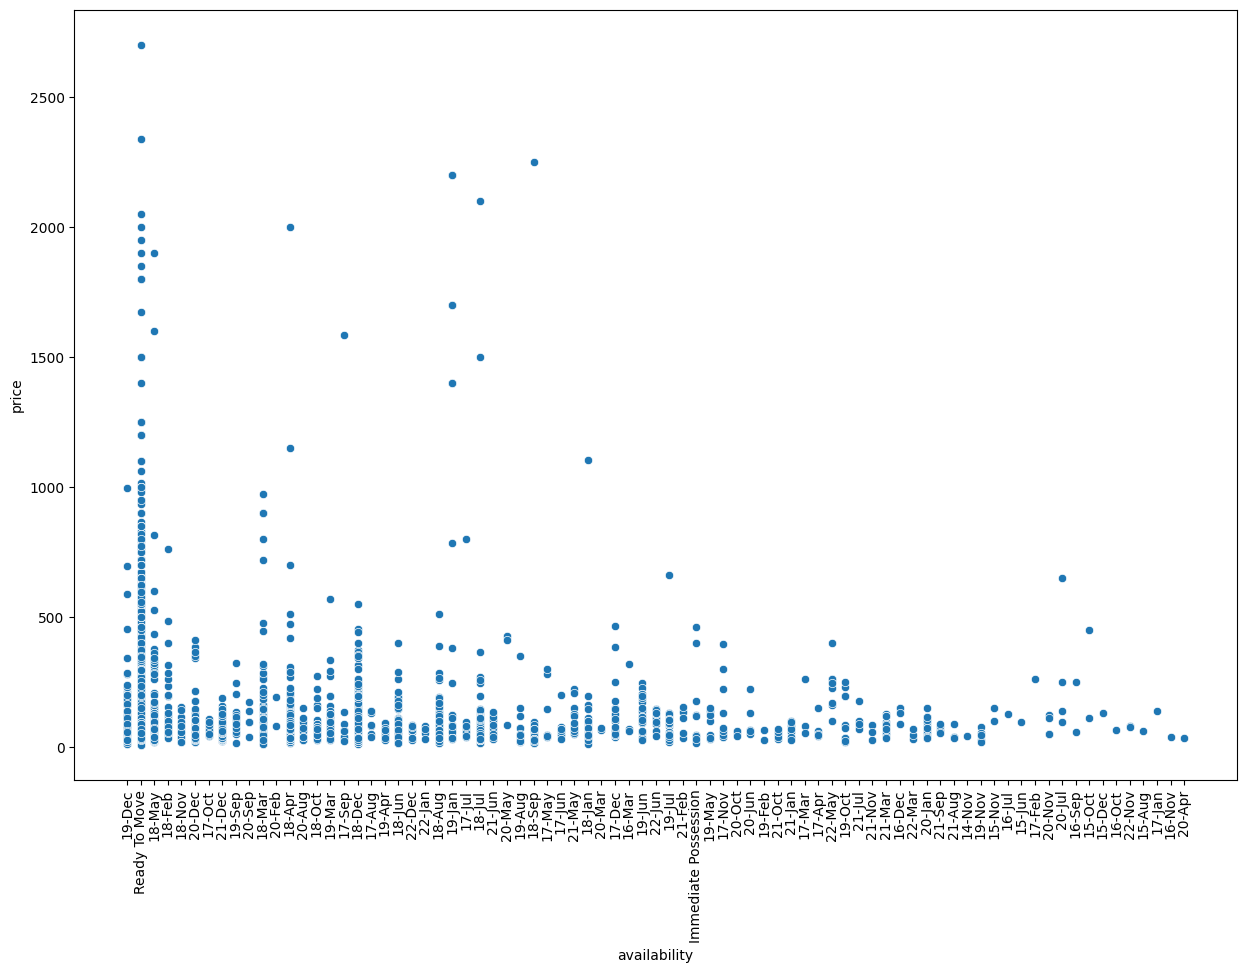

In [324]:
plt.figure(figsize=(15,10))
sns.scatterplot(x='availability', y='price', data=train_df)
plt.xticks(rotation=90)
plt.show()

##### Will remove this 'availability' features 

In [325]:
train_df_copy['location'].unique().tolist()

['Electronic City Phase II',
 'Chikka Tirupathi',
 'Uttarahalli',
 'Lingadheeranahalli',
 'Kothanur',
 'Whitefield',
 'Old Airport Road',
 'Rajaji Nagar',
 'Marathahalli',
 'Gandhi Bazar',
 '7th Phase JP Nagar',
 'Gottigere',
 'Sarjapur',
 'Mysore Road',
 'Bisuvanahalli',
 'Raja Rajeshwari Nagar',
 'Ramakrishnappa Layout',
 'Manayata Tech Park',
 'Kengeri',
 'Binny Pete',
 'Thanisandra',
 'Bellandur',
 ' Thanisandra',
 'Mangammanapalya',
 'Electronic City',
 'Ramagondanahalli',
 'Yelahanka',
 'Hebbal',
 'Kasturi Nagar',
 'Kanakpura Road',
 'Electronics City Phase 1',
 'Kundalahalli',
 'Chikkalasandra',
 'Murugeshpalya',
 'Sarjapur  Road',
 'Ganga Nagar',
 'HSR Layout',
 'Doddathoguru',
 'KR Puram',
 'Himagiri Meadows',
 'Adarsh Nagar',
 'Bhoganhalli',
 'Lakshminarayana Pura',
 'Begur Road',
 'Devanahalli',
 'Govindaraja Nagar Ward',
 'Tharabanahalli',
 'Varthur',
 'Bommanahalli',
 'Gunjur',
 'Devarachikkanahalli',
 'Double Road',
 'Hegde Nagar',
 'Haralur Road',
 'Hennur Road',
 'Kotha

In [326]:
train_df_copy['location'].nunique()

1197

##### Here some values are having spelling issue which we will correct it.

In [327]:
train_df_copy['size'].unique()

array(['2 BHK', '4 Bedroom', '3 BHK', '4 BHK', '6 Bedroom', '3 Bedroom',
       '1 BHK', '1 RK', '1 Bedroom', '8 Bedroom', '2 Bedroom',
       '7 Bedroom', '5 BHK', '7 BHK', '6 BHK', '5 Bedroom', '11 BHK',
       '9 BHK', nan, '9 Bedroom', '27 BHK', '10 Bedroom', '11 Bedroom',
       '10 BHK', '19 BHK', '16 BHK', '43 Bedroom', '14 BHK', '8 BHK',
       '12 Bedroom', '13 BHK'], dtype=object)

##### Will make 1 RK as 0 and will strip the value to remove string from the column, and none values to Mode.

In [328]:
train_df_copy['total_sqft']

0        1056
1        2600
2        1440
3        1521
4        1200
         ... 
10651    1200
10652    1260
10653    1092
10654     827
10655    1357
Name: total_sqft, Length: 10656, dtype: object

##### 'total_sqft' column is in object. Will check if there are any non-numeric values.

In [329]:
def check_float(x):
    try:
        float(x)
    except:
        return False
    return True

In [330]:
train_df_copy[~train_df_copy['total_sqft'].apply(lambda x : check_float(x))]['total_sqft'].unique()

array(['2100 - 2850', '3010 - 3410', '2957 - 3450', '3067 - 8156',
       '1042 - 1105', '1145 - 1340', '1015 - 1540', '1520 - 1740',
       '34.46Sq. Meter', '1195 - 1440', '1200 - 2400', '4125Perch',
       '1120 - 1145', '4400 - 6640', '3090 - 5002', '4400 - 6800',
       '1160 - 1195', '1000Sq. Meter', '4000 - 5249', '1115 - 1130',
       '1100Sq. Yards', '520 - 645', '1000 - 1285', '3606 - 5091',
       '650 - 665', '633 - 666', '5.31Acres', '30Acres', '1445 - 1455',
       '884 - 1116', '850 - 1093', '1440 - 1884', '716Sq. Meter',
       '547.34 - 827.31', '580 - 650', '3425 - 3435', '1804 - 2273',
       '3630 - 3800', '660 - 670', '1500Sq. Meter', '620 - 933',
       '142.61Sq. Meter', '2695 - 2940', '2000 - 5634', '1574Sq. Yards',
       '3450 - 3472', '1250 - 1305', '670 - 980', '1005.03 - 1252.49',
       '1004 - 1204', '361.33Sq. Yards', '645 - 936', '2710 - 3360',
       '2249.81 - 4112.19', '3436 - 3643', '2830 - 2882', '596 - 804',
       '1255 - 1863', '1300 - 1405', '1

##### We can see that many values are having ranges and some values are having units. We will take range values as average of the range, and unit values will be None. 

In [331]:
train_df_copy['bath'].value_counts()

bath
2.0     5530
3.0     2608
4.0      991
1.0      639
5.0      411
6.0      216
7.0       86
8.0       48
9.0       35
10.0      11
12.0       7
16.0       2
11.0       2
27.0       1
14.0       1
40.0       1
15.0       1
13.0       1
Name: count, dtype: int64

Now we will do all above steps in function for better reusability.

In [332]:
test_df.isna().sum()

ID                 0
area_type          0
availability       0
location           0
size               2
society         1074
total_sqft         0
bath               8
balcony          105
dtype: int64

In [333]:
train_df.columns

Index(['ID', 'area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [334]:
soc = train_df_copy.society.value_counts()

In [335]:
soc[soc>20].count()

30

In [336]:
train_df_copy.drop(columns='ID').duplicated().sum()

345

In [337]:
train_df_copy.drop(columns='ID').drop_duplicates(inplace=True)

In [338]:
del_col = ['ID','availability', 'balcony']

In [339]:
def get_size_value(x):
    if pd.isna(x):
        return x
    return x.split()[0]

In [340]:
def get_sq_ft(x):
    if check_float(x):
        return x
    else:
        val = x.split(' - ')
        if len(val) == 2:
            return (float(val[0])+float(val[1]))/2
        return None

In [341]:
def check_insance(x):
    if isinstance(x, list):
        return any
    elif isinstance(x, tuple):
        return all


In [342]:
def loc_clean(x):
    x = x.lower()
    x = re.sub(r'[, !&. /-]', '', x)
    return x

In [343]:
loc = {
    '1st Block HRBR Layout' : ('hrbr', '1stblock'),
    '2nd Block Hrbr Layout' : ('hrbr', '2ndblock'),
    '3rd Block Hrbr Layout' : ('hrbr', '3rdblock'),
    'HRBR Layout' : ('hrbr',),
    'Vijayanagar' : ['vijayanagar', 'vijaynagar'],
    '1st Block Jayanagar' : ('jayanagar', '1stblock'),
    '2nd Block Jayanagar' : ('jayanagar', '2ndblock'),
    '4th T block Jayanagar' : ('jayanagar', '4thblock'),
    '7th Block Jayanagar' : ('jayanagar', '7thblock'),
    '9th Block Jayanagar' : ('jayanagar', '9thblock'),
    'Jayanagar' : ('jayanagar',),
    '1st Block Koramangala' : ('koramangala', '1stblock'),
    '4th Block Koramangala' : ('koramangala', '4thblock'),
    '6th block Koramangala' : ('koramangala', '6thblock'),
    '8th block Koramangala' : ('koramangala', '8thblock'),
    'Koramangala' : ('koramangala',),
    '1st Phase JP Nagar' : ('jpnagar', '1stphase'),
    '2nd Phase JP Nagar' : ('jpnagar', '2ndphase'),
    '4th Phase JP Nagar' : ('jpnagar', '4thphase'),
    '5th Phase JP Nagar' : ('jpnagar', '5thphase'),
    '6th Phase JP Nagar' : ('jpnagar', '6thphase'),
    '7th Phase JP Nagar' : ('jpnagar', '7thphase'),
    '8th Phase JP Nagar' : ('jpnagar', '8thphase'),
    '9th Phase JP Nagar' : ('jpnagar', '9thphase'),
    'JP Nagar' : ('jpnagar',),
    'Indira Nagar' : ('indiranagar',),
    '2nd Phase Judicial Layout' : ('judicial', '2ndphase'),
    'Judicial Layout' : ('judicial',),
    '2nd Stage Nagarbhavi' : ('nagarbhavi', '2ndstage'),
    'Nagarbhavi' : ('nagarbhavi',),
    'Banashankari' : ('banashankari',),
    '5th Block Hbr Layout' : ('hbrlayout', '5thblock'),
    'HBR Layout' : ('hbrlayout',),
    'Mahalakshmi Puram' : ('mahalakshmi',),
    'Lakshminarayana Pura' : ['lakshminarayanapura', 'lakshmipura'],
    'Lakshmi Layout' : ('lakshmi',),
    'A Narayanapura' : ('anarayanapura',),
    'B Narayanapura' : ('bnarayanapura',),
    'Narayanapura' : ('narayanapura',),
    'Abbigere' : ('abbigere',),
    'AECS Layout' : ('aecslayout',),
    'AGS Layout' : ('agslayout',),
    'Akshayanagara East' : ('akshayanagaraeast',),
    'Akshaya Nagar' : ['akshaya', 'akshya'],
    'Ambalipura' : ['ambalipura', 'amblipura'],
    'Ambedkar Nagar' : ('ambedkar',),
    'Amruthahalli' : ('amruthahalli',),
    'Anand Nagar' : ('anandnagar',),
    'Anandapura' : ('anandapura',),
    'Ananth Nagar' : ('ananthnagar',),
    'Anekal' : ('anekal',) ,
    'Anjanapura' : ('anjanapura',) ,
    'Ardendale' : ('ardendale',) ,
    'Arekere' : ('arekere',) ,
    'Ashwath Nagar' : ('ashwathnagar',) ,
    'Sarjapur' : ('sarjapur',) ,
    'Attibele' : ('attibele',) ,
    'Attur Layout' : ('attur',) ,
    'Austin Town' : ('austintown',) ,
    'Babusapalaya' : ('babusapalaya',) ,
    'Badavala Nagar' : ('badavalanagar',) ,
    'Bagalakunte' : ('bagalakunte',) ,
    'Bagalur' : ('bagalur',) ,
    'Balagere' : ('balagere',) ,
    'Banagiri Nagar' : ('banagirinagar',) ,
    'Hormavu' : ['horamavu', 'hormavu'] ,
    'Banaswadi' : ('banaswadi',) ,
    'Banjara Layout' : ('banjaralayout',) ,
    'Bannerghatta Road' : ('bannerghattaroad',) ,
    'Bannerghatta' : ('bannerghatta',) ,
    'Basapura' : ('basapura',) ,
    'Basavanagara' : ['basavanagar', 'basavanagara'] ,
    'Basavanapura' : ('basavanapura',) ,
    'Basavangudi' : ('basavangudi',) ,
    'Basaveshwara Nagar' : ['basaveshwaranagar', 'basaveswarnagar'] ,
    'Basaveshwara Nagar Yelahanka' : ('basaveshwaranagaryelahanka',) ,
    'Battarahalli' : ['battarahalli', 'bhattarahalli'] ,
    'Begur' : ('begur',) ,
    'Begur Road' : ('begurroad',) ,
    'Belathur' : ['belathur', 'belatur'] ,
    'Bellandur' : ('bellandur',) ,
    'BEML Layout' : ('bemllayout',) ,
    'Benson Town' : ('bensontown',) ,
    'Bharathi Nagar' : ['bharathinagar', 'bharathnagar', 'bharatnagar'] ,
    'Bhoganhalli' : ('bhoganhalli',) ,
    'Bhuvaneshwari Nagar' : ['bhuvaneshwarinagar', 'bhuvaneswarinagar'] ,
    'Billekahalli' : ('billekahalli',) ,
    'Binny Pete' : ('binnypete',) ,
    'Bisuvanahalli' : ('bisuvanahalli',) ,
    'Bommanahalli' : ('bommanahalli',) ,
    'Doddabommasandra' : ('doddabommasandra',) ,
    'Bommasandra' : ('bommasandra',) ,
    'Bommasandra Industrial Area' : ('bommasandraindustrialarea',) ,
    'Bommenahalli' : ('bommenahalli',) ,
    'Brookefield' : ('brookefield',) ,
    'BTM 1st Stage' : ('btm', '1st') ,
    'BTM 2nd Stage' : ('btm', '2nd') ,
    'BTM Layout' : ('btm',) ,
    'Budigere' : ('budigere',) ,
    'Byadarahalli' : ('byadarahalli',) ,
    'Byatarayanapura' : ('byatarayanapura',) ,
    'Byrasandra' : ('byrasandra',) ,
    'Cambridge Layout' : ('cambridgelayout',) ,
    'Canara Bank Colony' : ('canarabank',) ,
    'Chamrajpet' : ('chamrajpet',) ,
    'Chandapura' : ('chandapura',) ,
    'Chandra Layout' : ('chandralayout',) ,
    'Channasandra' : ('channasandra',) ,
    'Chelekare' : ('chelekare',) ,
    'Chennammana Kere' : ('chennammanakere',) ,
    'Chikkalasandra' : ('chikkalasandra',) ,
    'Choodasandra' : ('choodasandra',) ,
    'Cooke Town' : ('cooketown',) ,
    'Cottonpet' : ('cottonpet',) ,
    'Cox Town' : ('coxtown',) ,
    'Cunningham Road' : ('cunninghamroad',) ,
    'CV Raman Nagar' : ('cvramannagar',) ,
    'Dairy Circle' : ('dairycircle',) ,
    'Dasanapura' : ('dasanapura',) ,
    'Dasarahalli' : ('dasarahalli',) ,
    'Devanahalli' : ('devanahalli',) ,
    'Devarachikkanahalli' : ('devarachikkanahalli',) ,
    'Doddaballapur' : ('doddaballapur',) ,
    'Doddakallasandra' : ('doddakallasandra',) ,
    'Doddanekundi' : ['doddanekundi', 'doddanekkundi'] ,
    'Doddathoguru' : ('thoguru',) ,
    'Dodsworth Layout' : ('dodsworthlayout',) ,
    'Dollars Colony' : ('dollars',) ,
    'Domlur' : ('domlur',) ,
    'Dommasandra' : ('dommasandra',) ,
    'Ejipura' : ('ejipura',) ,
    'Electronic City Phase II' : ('electronic', 'phaseii') ,
    'Electronics City Phase 1' : ('electronic', 'phase1') ,
    'Electronic City' : ('electronic',) ,
    'EPIP Zone' : ('epip',) ,
    'Frazer Town' : ['frazertown', 'frasertown'] ,
    'Ganga Nagar' : ('ganganagar',) ,
    'Garudachar Palya' : ('garudacharpalya',) ,
    'Giri Nagar' : ('girinagar',) ,
    'GM Palaya' : ('gmpalaya',) ,
    'Gollahalli' : ('gollahalli',) ,
    'Gollarapalya Hosahalli' : ('gollarapalyahosahalli',) ,
    'Gopalkrishna Nagar' : ('gopalkrishnanagar',) ,
    'Gottigere' : ('gottigere',) ,
    'Govindpura' : ['govindpura', 'govindapura'] ,
    'Green Glen Layout' : ('greenglenlayout',) ,
    'Gubbalala' : ('gubbalala',) ,
    'Gunjur Palya' : ('gunjurpalya',) ,
    'Gunjur' : ('gunjur',) ,
    'HAL 2nd Stage' : ('hal2ndstage',) ,
    'Haralur Road' : ('haralurroad',) ,
    'Harlur' : ('harlur',) ,
    'Harsha Layout' : ('harshalayout',) ,
    'Hebbal Kempapura' : ('hebbalkempapura',) ,
    'Hebbal' : ('hebbal',) ,
    'Hegde Nagar' : ('hegdenagar',) ,
    'Hennur Bande' : ('hennurbande',) ,
    'Hennur Gardens' : ('hennurgardens',) ,
    'Hennur Road' : ('hennurroad',) ,
    'Hennur' : ('hennur',) ,
    'Herohalli' : ('herohalli',) ,
    'Hessarghatta' : ('hessarghatta',) ,
    'Hiremath Layout' : ('hiremathlayout',) ,
    'HMT Layout' : ('hmtlayout',) ,
    'Hongasandra' : ('hongasandra',) ,
    'Hoodi' : ('hoodi',) ,
    'Hosa Road' : ('hosaroad',) ,
    'Hosahalli Extension' : ('hosahalli',) ,
    'Hoskote' : ('hoskote',) ,
    'Hosur Road' : ('hosur',) ,
    'Hoysalanagar' : ('hoysalanagar',) ,
    'Sector 1 HSR Layout' : ('hsrlayout', '1') ,
    'Sector 2 HSR Layout' : ('hsrlayout', '2') ,
    'Sector 6 HSR Layout' : ('hsrlayout', '6') ,
    'Sector 7 HSR Layout' : ('hsrlayout', '7') ,
    'HSR Layout' : ('hsrlayout',) ,
    'Hulimavu' : ('hulimavu',) ,
    'Huskur' : ('huskur',) ,
    'Iblur Village' : ('iblurvillage',) ,
    'Immadihalli' : ('immadihalli',) ,
    'ISRO Layout' : ('isrolayout',) ,
    'ITI Layout' : ('itilayout',) ,
    'ITPL' : ('itpl',) ,
    'Ittamadu' : ('ittamadu',) ,
    'Jakkasandra Extension' : ('jakkasandraextension',) ,
    'Jakkur Plantation' : ('jakkurplantation',) ,
    'Jakkuru Layout' : ('jakkurulayout',) ,
    'Jakkur' : ('jakkur',) ,
    'Jalahalli East' : ('jalahallieast',) ,
    'Jalahalli West' : ('jalahalliwest',) ,
    'Jalahalli' : ('jalahalli',) ,
    'JCR Layout' : ('jcrlayout',) ,
    'Jeevan bima nagar' : ('jeevanbimanagar',) ,
    'Jigani' : ('jigani',) ,
    'Jnanabharathi Layout' : ('jnanabharathilayout',) ,
    'Kacharakanahalli' : ('kacharakanahalli',) ,
    'Kada Agrahara' : ('kadaagrahara',) ,
    'Kadabagere' : ('kadabagere',) ,
    'Kadubeesanahalli' : ('kadubeesanahalli',) ,
    'Kadugodi' : ('kadugodi',) ,
    'Kadugondanahalli' : ('kadugondanahalli',) ,
    'Kaggadasapura' : ('kaggadasapura',) ,
    'Kaggalipura' : ('kaggalipura',) ,
    'Kaikondrahalli' : ('kaikondrahalli',) ,
    'Kalena Agrahara' : ('kalenaagrahara',) ,
    'Kalkere' : ('kalkere',) ,
    'Kallumantapa' : ('kallumantapa',) ,
    'Kalyan nagar' : ('kalyannagar',) ,
    'Kamakshipalya' : ('kamakshipalya',) ,
    'Kamala Nagar' : ('kamalanagar',) ,
    'Kambipura' : ('kambipura',) ,
    'Kammagondahalli' : ('kammagondahalli',) ,
    'Kammanahalli' : ('kammanahalli',) ,
    'Kammasandra' : ('kammasandra',) ,
    'Kanaka Nagar' : ('kanakanagar',) ,
    'Kanakpura Road' : ['kanakpuraroad', 'kanakapuraroad', 'kanakapuramainroad'] ,
    'Kanakapura' : ('kanakapura',) ,
    'Kannamangala' : ('kannamangala',) ,
    'Karuna Nagar' : ('karunanagar',) ,
    'Kasavanhalli' : ('kasavanhalli',) ,
    'Kasturi Nagar' : ('kasturinagar',) ,
    'Kathriguppe' : ['kathriguppe', 'kathreguppe'] ,
    'Kattigenahalli' : ('kattigenahalli',) ,
    'Kaval Byrasandra' : ('kavalbyrasandra',) ,
    'Kaverappa Layout' : ('kaverappalayout',) ,
    'Kenchenahalli' : ['kenchenahalli', 'kenchenhalli'] ,
    'Kengeri Satellite Town' : ('kengerisatellitetown',) ,
    'Kengeri' : ('kengeri',) ,
    'Kereguddadahalli' : ('kereguddadahalli',) ,
    'Keshava Nagar' : ('keshavanagar',) ,
    'Kirloskar Layout' : ('kirloskarlayout',) ,
    'Kodathi' : ('kodathi',) ,
    'Kodbisanhalli' : ('kodbisanhalli',) ,
    'Kodichikkanahalli' : ('kodichikkanahalli',) ,
    'Kodigehalli' : ['kodigehaali', 'kodigehalli'] ,
    'Kodihalli' : ('kodihalli',) ,
    'Kogilu' : ('kogilu',) ,
    'Konanakunte' : ('konanakunte',) ,
    'Kothanur' : ['kothannur', 'kothanur'] ,
    'KR Garden' : ('krgarden',) ,
    'KR Puram' : ('krpuram',) ,
    'Kudlu Gate' : ('kudlugate',) ,
    'KUDLU MAIN ROAD' : ('kudlumainroad',) ,
    'Kudlu' : ('kudlu',) ,
    'Kumara Park' : ('kumarapark',) ,
    'Kumarapalli' : ('kumarapalli',) ,
    'Kumaraswami Layout' : ('kumaraswamilayout',) ,
    'Kundalahalli Colony' : ('kundalahallicolony',) ,
    'Kundalahalli' : ('kundalahalli',) ,
    'Kurubarahalli' : ('kurubarahalli',) ,
    'Kuvempu Nagar' : ('kuvempunagar',) ,
    'Laggere' : ('laggere',) ,
    'Lake City' : ('lakecity',) ,
    'Langford Town' : ('langfordtown',) ,
    'Lavakusha Nagar' : ('lavakushanagar',) ,
    'Lavelle Road' : ('lavelleroad',) ,
    'Laxmi Sagar Layout' : ('laxmisagarlayout',) ,
    'LB Shastri Nagar' : ('lbshastrinagar',) ,
    'Lingadheeranahalli' : ('lingadheeranahalli',) ,
    'Lingarajapuram' : ('lingarajapuram',) ,
    'Madiwala' : ('madiwala',) ,
    'Magadi Road' : ('magadiroad',) ,
    'Mahadevpura' : ('mahadevpura',) ,
    'Maithri Layout' : ('maithrilayout',) ,
    'Mallasandra' : ('mallasandra',) ,
    'Mallathahalli' : ('mallathahalli',) ,
    'Malleshpalya' : ('malleshpalya',) ,
    'Malleshwaram' : ('malleshwaram',) ,
    'Manayata Tech Park' : ('manayatatechpark',) ,
    'Manjunath Nagar' : ('manjunathnagar',) ,
    'Maragondanahalli' : ('maragondanahalli',) ,
    'Marathahalli' : ('marathahalli',) ,
    'Margondanahalli' : ('margondanahalli',) ,
    'Marsur' : ('marsur',) ,
    'Maruthi Nagar' : ('maruthinagar',) ,
    'Maruthi Sevanagar' : ('maruthisevanagar',) ,
    'Mathikere' : ('mathikere',) ,
    'MCECHS  layout' : ('mcechslayout',) ,
    'Medahalli' : ('medahalli',) ,
    'Meenakunte' : ('meenakunte',) ,
    'Mico Layout' : ('micolayout',) ,
    'Motappa Layout' : ('motappalayout',) ,
    'MS Pallya' : ('mspallya',) ,
    'Munivenkatppa Layout' : ('munivenkatppalayout',) ,
    'Munnekollal' : ('munnekollal',) ,
    'Murugeshpalya' : ('murugeshpalya',) ,
    'Mylasandra' : ('mylasandra',) ,
    'Mysore Highway' : ('mysorehighway',) ,
    'Mysore Road' : ('mysoreroad',) ,
    'Nagadevanahalli' : ('nagadevanahalli',) ,
    'Naganathapura' : ('naganathapura',) ,
    'Nagappa Reddy Layout' : ('nagappareddylayout',) ,
    'Nagaraja Garden' : ('nagarajagarden',) ,
    'Nagasandra' : ('nagasandra',) ,
    'Nagashetty Halli' : ('nagashettyhalli',) ,
    'Nagavarapalya' : ('nagavarapalya',) ,
    'Nagavara' : ('nagavara',) ,
    'Nagawara Junction' : ('nagawarajunction',) ,
    'Nagondanahalli' : ('nagondanahalli',) ,
    'Nallurhalli' : ('nallurhalli',) ,
    'Nayandanahalli' : ('nayandanahalli',) ,
    'Neeladri Nagar' : ('neeladrinagar',) ,
    'Nehru Nagar' : ('nehrunagar',) ,
    'Nelamangala' : ('nelamangala',) ,
    'New Gurappana Palya' : ('newgurappanapalya',) ,
    'New Thippasandra' : ('newthippasandra',) ,
    'Ngef Layout' : ('ngeflayout',) ,
    'NGR Layout' : ('ngrlayout',) ,
    'NRI Layout' : ('nrilayout',) ,
    'NS Palya' : ('nspalya',) ,
    'Old Airport Road' : ('oldairportroad',) ,
    'OLd Gurappanapalya' : ('oldgurappanapalya',) ,
    'Old Madras Road' : ('oldmadrasroad',) ,
    'OMBR Layout' : ('ombrlayout',) ,
    'Outer Ring Road East' : ('outerringroadeast',) ,
    'Padmanabhanagar' : ('padmanabhanagar',) ,
    'Pai Layout' : ('pailayout',) ,
    'Panathur' : ('panathur',) ,
    'Parappana Agrahara' : ('parappanaagrahara',) ,
    'Pattanagere' : ('pattanagere',) ,
    'Pattandur Agrahara' : ('pattanduragrahara',) ,
    'Peenya' : ('peenya',) ,
    'Poorna Pragna Layout' : ('poornapragnalayout',) ,
    'Prithvi Layout' : ('prithvilayout',) ,
    'Puttanahalli' : ('puttanahalli',) ,
    'R.T. Nagar' : ('rtnagar',) ,
    'Rachenahalli' : ('rachenahalli',) ,
    'Raghuvanahalli' : ('raghuvanahalli',) ,
    'Raja Rajeshwari Nagar 5th Stage' : ('rajarajeshwarinagar5thstage',) ,
    'Raja Rajeshwari Nagar' : ('rajarajeshwarinagar',) ,
    'Rajaji Nagar' : ('rajajinagar',) ,
    'Rajiv Gandhi Nagar' : ('rajivgandhinagar',) ,
    'Rajiv Nagar' : ('rajivnagar',) ,
    'Ramagondanahalli' : ('ramagondanahalli',) ,
    'Ramakrishnappa Layout' : ('ramakrishnappalayout',) ,
    'Ramamurthy Nagar' : ('ramamurthynagar',) ,
    'Ramamurthy Nagar Extension' : ('ramamurthynagarextension',) ,
    'Ramanjaneyanagar' : ('ramanjaneyanagar',) ,
    'Rayasandra' : ('rayasandra',) ,
    'Reliaable Tranquil Layout' : ('reliaabletranquillayout',) ,
    'Richards Town' : ('richardstown',) ,
    'Richmond Town' : ('richmondtown',) ,
    'RMV Extension' : ('rmv',) ,
    'RMV 2nd Stage' : ('rmv2ndstage',) ,
    'Roopena Agrahara' : ('roopenaagrahara',) ,
    'Rustam Bagh Layout' : ('rustambaghlayout',) ,
    'RWF West Colony' : ('rwfwestcolony',) ,
    'Sadashiva Nagar' : ('sadashivanagar',) ,
    'Sahakara Nagar' : ('sahakaranagar',) ,
    'Sai Gardens' : ('saigardens',) ,
    'Samethanahalli' : ('samethanahalli',) ,
    'Sanjay nagar' : ('sanjaynagar',) ,
    'Sarakki Nagar' : ('sarakkinagar',) ,
    'Sathya Sai Layout' : ('sathyasailayout',) ,
    'Seegehalli' : ('seegehalli',) ,
    'Seetharampalya' : ('seetharampalya',) ,
    'Shampura' : ('shampura',) ,
    'Shankarapuram' : ('shankarapuram',) ,
    'Shanthala Nagar' : ('shanthalanagar',) ,
    'Shanti Nagar' : ('shantinagar',) ,
    'Shantiniketan Layout' : ('shantiniketanlayout',) ,
    'Shikaripalya' : ('shikaripalya',) ,
    'Shivaji Nagar' : ('shivajinagar',) ,
    'Siddapura' : ('siddapura',) ,
    'Sidedahalli' : ('sidedahalli',) ,
    'Silk Board' : ('silkboard',) ,
    'Singapura Village' : ('singapuravillage',) ,
    'Singasandra' : ('singasandra',) ,
    'Singena Agrahara' : ('singenaagrahara',) ,
    'Somasundara Palya' : ('somasundarapalya',) ,
    'Sompura' : ('sompura',) ,
    'Sonnenahalli' : ('sonnenahalli',) ,
    'Srinivasa Nagar' : ('srinivasanagar',) ,
    'Srirampura' : ('srirampura',) ,
    'Srirampuram' : ('srirampuram',) ,
    'Stage-4 Bommanahalli' : ('stage4bommanahalli',) ,
    'Subramanyapura' : ('subramanyapura',) ,
    'Suddaguntepalya' : ('suddaguntepalya',) ,
    'Sultan Palaya' : ('sultanpalaya',) ,
    'Sunkadakatte' : ('sunkadakatte',) ,
    'Suraksha Nagar' : ('surakshanagar',) ,
    'Tala Cauvery Layout' : ('talacauverylayout',) ,
    'Talaghattapura' : ('talaghattapura',) ,
    'Tata Nagar' : ('tatanagar',) ,
    'TC Palaya' : ['tcpalaya', 'tcpalya'] ,
    'Tejaswini Nagar' : ('tejaswininagar',) ,
    'Thanisandra main road' : ('thanisandramainroad',) ,
    'Thanisandra' : ('thanisandra',) ,
    'Thigalarapalya' : ('thigalarapalya',) ,
    'Thirumenahalli' : ('thirumenahalli',) ,
    'Thubarahalli' : ('thubarahalli',) ,
    'Thyagaraja Nagar' : ('thyagarajanagar',) ,
    'Tindlu' : ('tindlu',) ,
    'Tumkur Road' : ('tumkurroad',) ,
    'Udaya Nagar' : ('udayanagar',) ,
    'Udayapur Village' : ('udayapurvillage',) ,
    'Ulsoor' : ('ulsoor',) ,
    'Upkar Layout' : ('upkarlayout',) ,
    'Uttarahalli' : ('uttarahalli',) ,
    'Vajarahalli' : ('vajarahalli',) ,
    'Varanasi' : ('varanasi',) ,
    'Varsova Layout' : ('varsovalayout',) ,
    'Varthur Road' : ('varthurroad',) ,
    'Varthur' : ('varthur',) ,
    'Vasanth nagar' : ('vasanthnagar',) ,
    'Vasantha Vallabha Nagar' : ('vasanthavallabhanagar',) ,
    'Vasanthapura' : ['vasanthapura', 'vasanthpura'] ,
    'Venkatapura' : ['venkatapura', 'venkateshpuram'] ,
    'VGP Layout' : ('vgplayout',) ,
    'Victoria Layout' : ('victorialayout',) ,
    'Vidyaranyapura' : ('vidyaranyapura',) ,
    'Vignana Nagar' : ('vignananagar',) ,
    'Vijaya Bank Layout' : ('vijayabank',) ,
    'Virat Nagar' : ('viratnagar',) ,
    'Vishveshwarya Layout' : ('vishveshwaryalayout',) ,
    'Vishwanatha Nagenahalli' : ('vishwanathanagenahalli',) ,
    'Vishwapriya Layout' : ['vishwapriyalayout', 'vishwapriyanagar'] ,
    'Vittasandra' : ('vittasandra',) ,
    'Volagerekallahalli' : ('volagerekallahalli',) ,
    'Whitefield' : ('white',) ,
    'Wilson Garden' : ('wilsongarden',) ,
    'Yelachenahalli' : ('yelachenahalli',) ,
    'Yelahanka New Town' : ('yelahankanewtown',) ,
    'Yelahanka' : ('yelahanka',) ,
    'Yelenahalli' : ('yelenahalli',) ,
    'Yemlur' : ('yemlur',) ,
    'Yeshwanthpur' : ('yeshwanthpur',) ,
    'Sarjapur  Road' : ('sarjapurroad',) ,
    'Horamavu Agara' : ('horamavuagara',) ,
    'Hosakerehalli' : ('hosakerehalli',) ,
    'Dodda Nekkundi' : ('doddanekkundi',) ,
    'Horamavu Banaswadi' : ('horamavubanaswadi',) ,
    'Banashankari Stage III' : ('banashankaristageiii',) ,
    'Kothannur' : ('kothannur',) ,
    'Sarjapura - Attibele Road' : ('sarjapuraattibeleroad',) ,
    'Chikka Tirupathi' : ('chikkatirupathi',) ,
    'Banashankari Stage II' : ('banashankaristageii',) ,
    'Banashankari Stage VI' : ('banashankaristagevi',) ,
    'Mahalakshmi Layout' : ('mahalakshmilayout',) ,
    'Chikkabanavar' : ('chikkabanavar',) ,
    'Kodigehaali' : ('kodigehaali',) ,
    'Banashankari Stage V' : ('banashankaristagev',) ,
    'Akshaya Vana' : ('akshayavana',) ,
    'Sarjapur Road,' : ('sarjapurroad',) ,
    'Dodda Nekkundi Extension' : ('doddanekkundiextension',) ,
    'Hoodi Circle,' : ('hoodicircle',) ,
    'Doctors Layout' : ('doctorslayout',) ,
    'Doddakammanahalli' : ('doddakammanahalli',) ,
    'Cholanayakanahalli' : ('cholanayakanahalli',) ,
    'Defence Colony' : ('defencecolony',) ,
    'Green View Layout' : ('greenviewlayout',) ,
    'Ambedkar Colony' : ('ambedkarcolony',) ,
    'Bank Of Baroda Colony' : ('bankofbarodacolony',) ,
    'HOSUR MAIN ROAD' : ('hosurmainroad',) ,
    'Channasandra Layout' : ('channasandralayout',) ,
    'Ashirvad Colony' : ('ashirvadcolony',) ,
    'Dodda Banaswadi' : ('doddabanaswadi',) ,
    'Devasthanagalu' : ('devasthanagalu',) ,
    'Amblipura' : ('amblipura',) ,
    'Ashwathnagar' : ('ashwathnagar',) ,
    'Abbaiah Reddy Layout' : ('abbaiahreddylayout',) ,
    'Shree Ananth Nagar Layout' : ('shreeananthnagarlayout',) ,
    'Byrathi Village' : ('byrathivillage',) ,
    'Devarabeesana Halli' : ('devarabeesanahalli',) ,
    'Doddanakundi Industrial Area 2' : ('doddanakundiindustrialarea2',) ,
    'Doddakannelli' : ('doddakannelli',) ,
    'Bileshivale' : ('bileshivale',) ,
    'Gopalapura' : ('gopalapura',) ,
    'Avalahalli' : ('avalahalli',) ,
    'Akshya Nagar' : ('akshyanagar',) ,
    '1st Stage Indira Nagar' : ('1ststageindiranagar',) ,
    'Amruthnagar' : ('amruthnagar',) ,
    'Carmelaram' : ('carmelaram',) ,
    'Coconut Grove Layout' : ('coconutgrovelayout',) ,
    'Off Sarjapur Road,' : ('offsarjapurroad',) ,
    'Doopanahalli' : ('doopanahalli',) ,
    'Doddabanahalli' : ('doddabanahalli',) ,
    '3rd Block Banashankari' : ('3rdblockbanashankari',) ,
    'Chikkadunnasandra' : ('chikkadunnasandra',) ,
    'Bellari Road' : ('bellariroad',) ,
    'Devi Nagar' : ('devinagar',) ,
    'Vishwapriya Nagar' : ('vishwapriyanagar',) ,
    'Byagadadhenahalli' : ('byagadadhenahalli',) ,
    'Chinnapanahalli' : ('chinnapanahalli',) ,
    'Doddagubbi' : ('doddagubbi',) ,
    'Geddalahalli' : ('geddalahalli',) ,
    'tc.palya' : ('tc.palya',) ,
    'Glass Factory Layout' : ('glassfactorylayout',) ,
    'Judicial Layout, Kanakapura Road,' : ('judiciallayout', 'kanakapuraroad',) ,
    'Chikkathoguru' : ('chikkathoguru',) ,
    'BEL Road' : ('belroad',) ,
    'Brooke Bond First Cross' : ('brookebondfirstcross',) ,
    'Bikasipura' : ('bikasipura',) ,
    'Alfa Garden Layout' : ('alfagardenlayout',) ,
    'AMS Layout' : ('amslayout',) ,
    'Basavanna Nagar' : ('basavannanagar',) ,
    'Konanakunte Cross' : ('konanakuntecross',) ,
    'Chennappa Layout' : ('chennappalayout',) ,
    'Gowdanapalya' : ('gowdanapalya',) ,
    'BSM Extension' : ('bsmextension',) ,
}

In [344]:
train_df_copy['location']

0              Electronic City Phase II
1                      Chikka Tirupathi
2                           Uttarahalli
3                    Lingadheeranahalli
4                              Kothanur
                      ...              
10651                Parappana Agrahara
10652                       Bhoganhalli
10653    Doddanakundi Industrial Area 2
10654                Kachanayakanahalli
10655                Horamavu Banaswadi
Name: location, Length: 10656, dtype: object

In [345]:
train_df_copy.dropna(subset=['location', 'size'], inplace=True)

In [346]:
def reuse_func(x):
    df = x.drop(columns=del_col, errors='ignore')

    df['size'] = df['size'].apply(get_size_value)

    df['size'] = df['size'].astype('float')

    df['total_sqft'] = df['total_sqft'].apply(get_sq_ft)

    df['total_sqft'] = df['total_sqft'].astype('float')

    # df['availability'] = df['availability'].apply(lambda x : 'Dates' if x not in ('Ready To Move', 'Immediate Possession') else x)

    df.dropna(subset=['location'], inplace=True)

    df['location'] = df['location'].apply(loc_clean)

    for val in loc:
        search_terms = loc[val] 
        mask = df['location'].apply(
            lambda x: check_insance(search_terms)(term in str(x) for term in search_terms)
        )   
        df.loc[mask, 'location'] = val

    df['dist_from_city'] = df['location'].map(city_dist.set_index('location')['dist_from_city'])
    
    # loc_count = df['location'].value_counts()
    # df['location'] = df['location'].apply(lambda x: 'Other' if x in loc_count[loc_count<=20] else x)

    return df

In [347]:
train_df_copy = reuse_func(train_df_copy)

In [348]:
loc_count = train_df_copy['location'].value_counts()
train_df_copy['location'] = train_df_copy['location'].apply(lambda x: 'Other' if x in loc_count[loc_count<=10] else x)

In [349]:
train_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10641 entries, 0 to 10655
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   area_type       10641 non-null  object 
 1   location        10641 non-null  object 
 2   size            10641 non-null  float64
 3   society         6216 non-null   object 
 4   total_sqft      10601 non-null  float64
 5   bath            10590 non-null  float64
 6   price           10641 non-null  float64
 7   dist_from_city  9859 non-null   float64
dtypes: float64(5), object(3)
memory usage: 748.2+ KB


In [350]:
avg_loc = train_df_copy.groupby('location')['total_sqft'].median()

In [351]:
def fill_val(x):
    df = x.copy()
    size_mode = df['size'].mode()[0]
    df['size'] = df['size'].fillna(size_mode)

    df['bath'] = df['bath'].fillna(df['size'])

    df['total_sqft'] = df['total_sqft'].fillna(df['location'].map(avg_loc))

    total_sqft_median = df['total_sqft'].median()
    df['total_sqft'] = df['total_sqft'].fillna(total_sqft_median)

    df.loc[df['dist_from_city'] > 20, 'dist_from_city'] = 20

    dist_from_city_median = df['dist_from_city'].median()
    df['dist_from_city'] = df['dist_from_city'].fillna(dist_from_city_median)

    return df

In [352]:
train_df_copy = fill_val(train_df_copy)

In [353]:
soc_count = train_df_copy['society'].value_counts()
train_df_copy['society'] = train_df_copy['society'].apply(lambda x: 'NoSociety' if x in soc_count[soc_count<=15] or pd.isna(x) else x)

In [354]:
train_df_copy.society.value_counts()

society
NoSociety    9338
GrrvaGr        70
PrarePa        58
Prtates        52
Prtanha        45
GMown E        45
Sryalan        45
Prityel        42
Prarkun        41
Bhmesy         39
Dhalsh         38
PrityTr        37
IBityin        35
Soresea        33
SNnia E        30
Rosha I        30
Adeatlm        27
Bhe 2ko        27
SunceEs        26
SNity S        26
Soitya         25
DLhtsnd        24
Prlla C        23
Raard B        23
MenueNo        23
RothaVa        23
JRrnauv        22
Puachal        22
GoAirej        21
Brnia G        21
PuandHi        21
Sodgere        20
Prncyrn        20
ViistLa        19
Soazak         19
Dieldli        19
Shitt S        19
DLhtsan        18
Brway G        18
Magiaya        18
RInceeg        18
Soiewre        18
PhestOn        18
Itelaa         18
PueraRi        18
Eladero        17
Jaades         16
PualeSk        16
Name: count, dtype: int64

In [355]:
train_df_copy.isna().sum()

area_type         0
location          0
size              0
society           0
total_sqft        0
bath              0
price             0
dist_from_city    0
dtype: int64

In [356]:
test_df_copy = reuse_func(test_df)
test_df_copy = fill_val(test_df_copy)

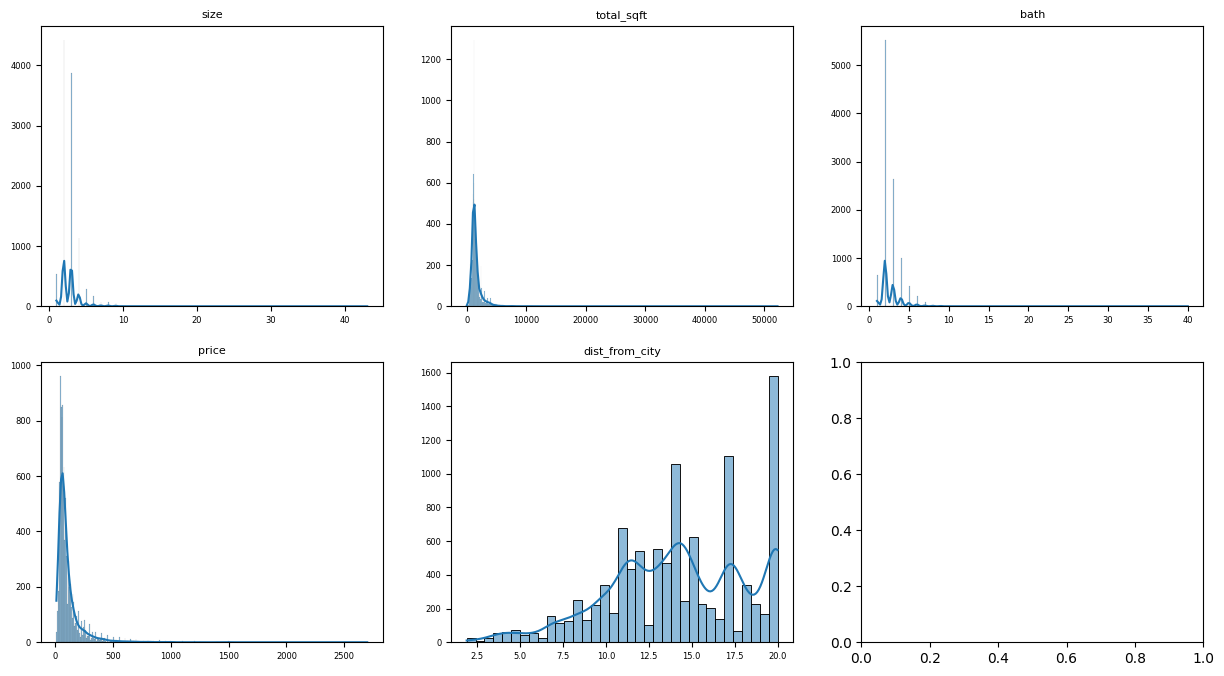

In [357]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

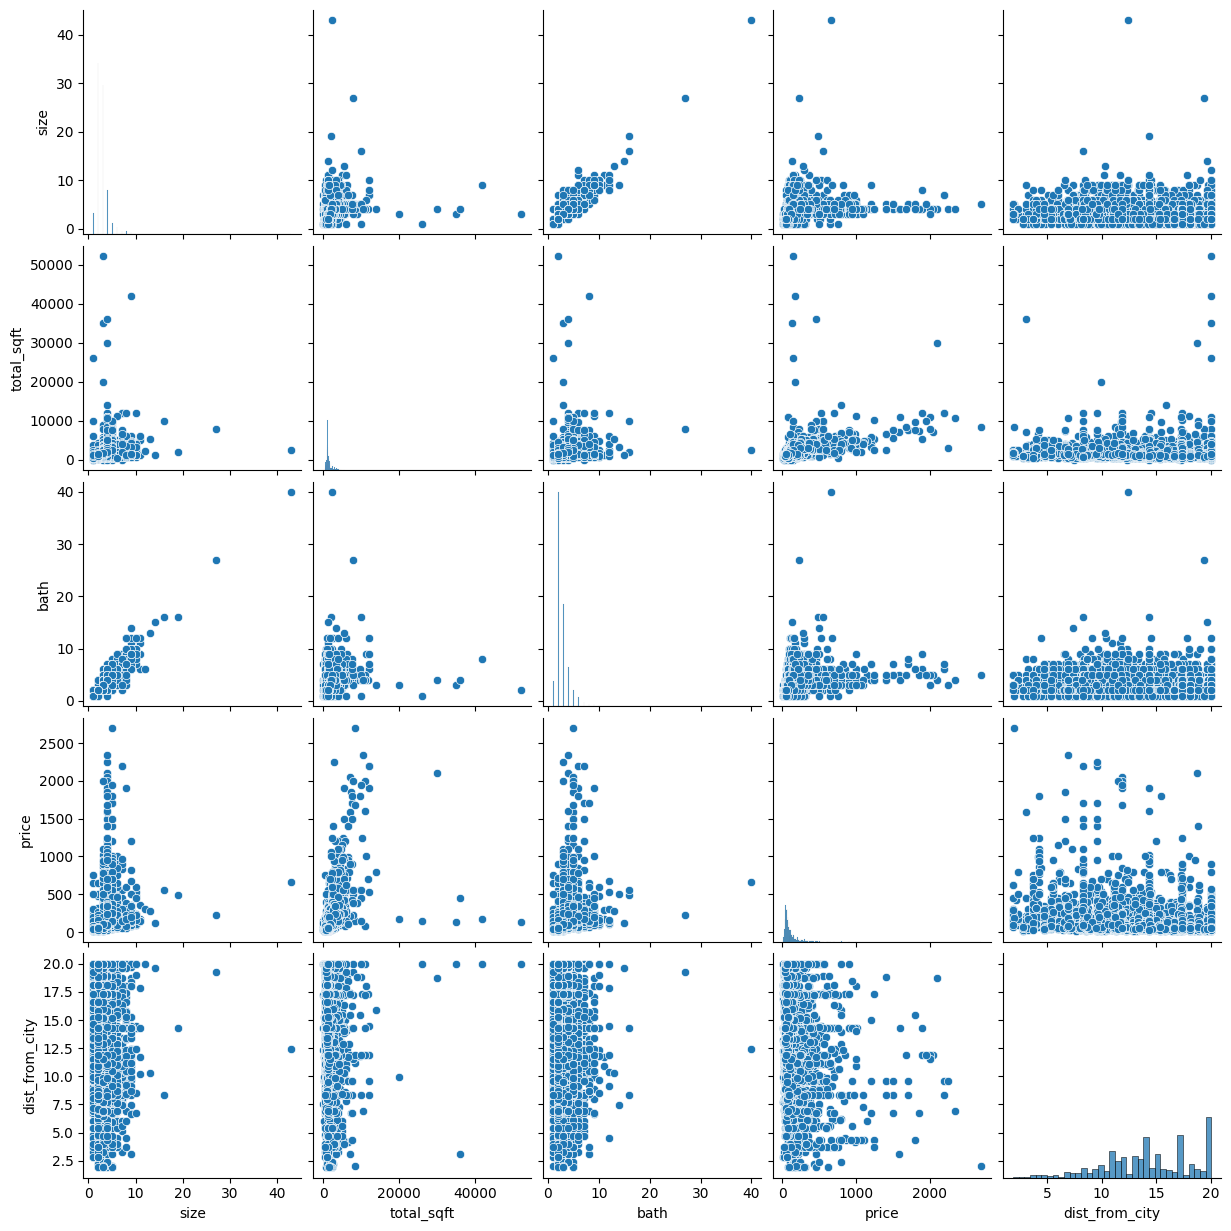

In [358]:
sns.pairplot(train_df_copy)

<Axes: xlabel='price', ylabel='Count'>

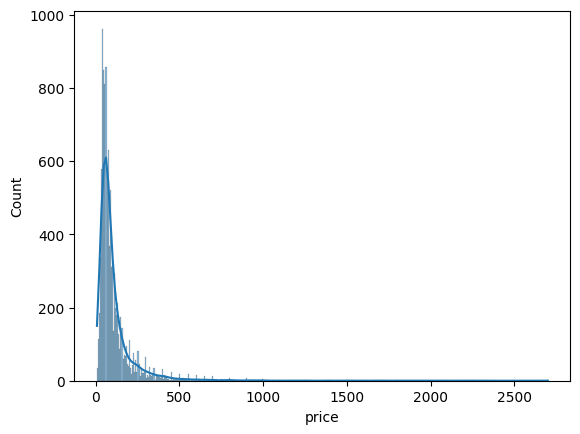

In [359]:
sns.histplot(data = train_df_copy, x = 'price', kde=True)

In [360]:
train_df_copy.shape

(10641, 8)

In [361]:
test_df_copy.loc[~test_df_copy['location'].isin(train_df_copy['location']), 'location'] = 'Other'

In [362]:
test_df_copy.loc[~test_df_copy['society'].isin(train_df_copy['society']), 'society'] = 'NoSociety'

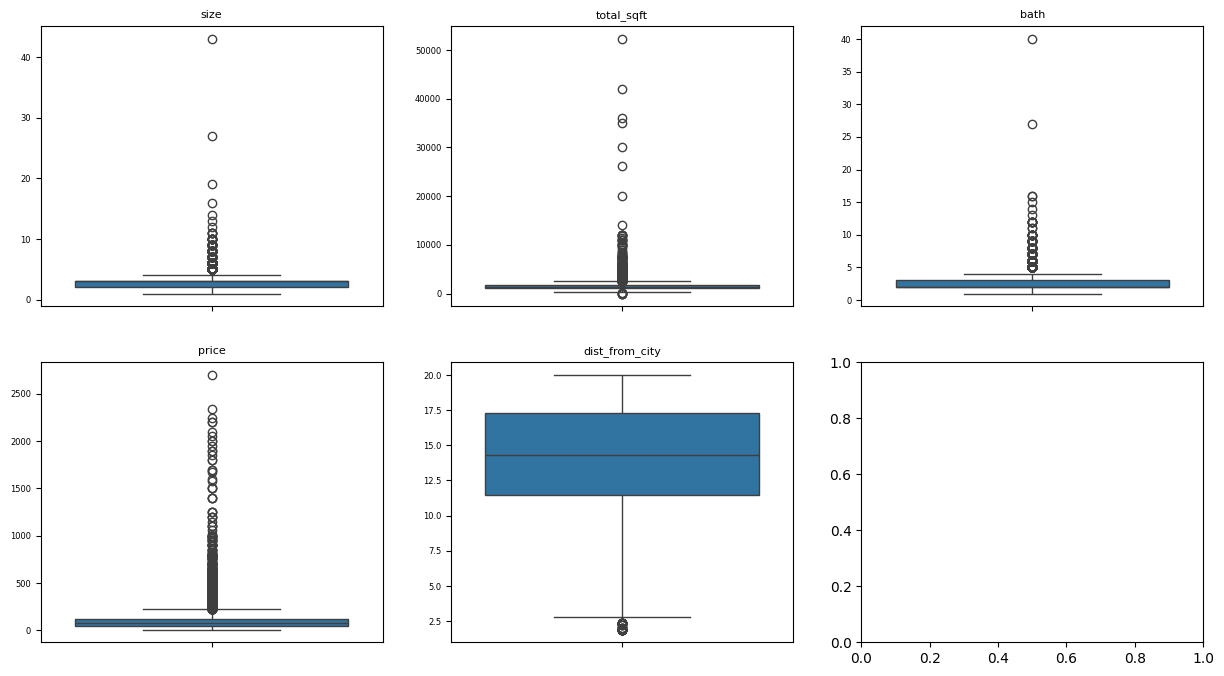

In [363]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [364]:
train_df_copy['price_per_sqft'] = train_df_copy['price']/train_df_copy['total_sqft']

In [365]:
train_df_copy['price_per_size'] = train_df_copy['price']/train_df_copy['size']

In [366]:
train_df_copy['sqft_per_size'] = train_df_copy['total_sqft']/train_df_copy['size']

In [367]:
test_df_copy['sqft_per_size'] = test_df_copy['total_sqft']/test_df_copy['size']

In [368]:
train_df_copy['price_per_size'].describe()

count    10641.000000
mean        38.019412
std         35.887374
min          3.333333
25%         21.666667
50%         29.000000
75%         41.250000
max        750.000000
Name: price_per_size, dtype: float64

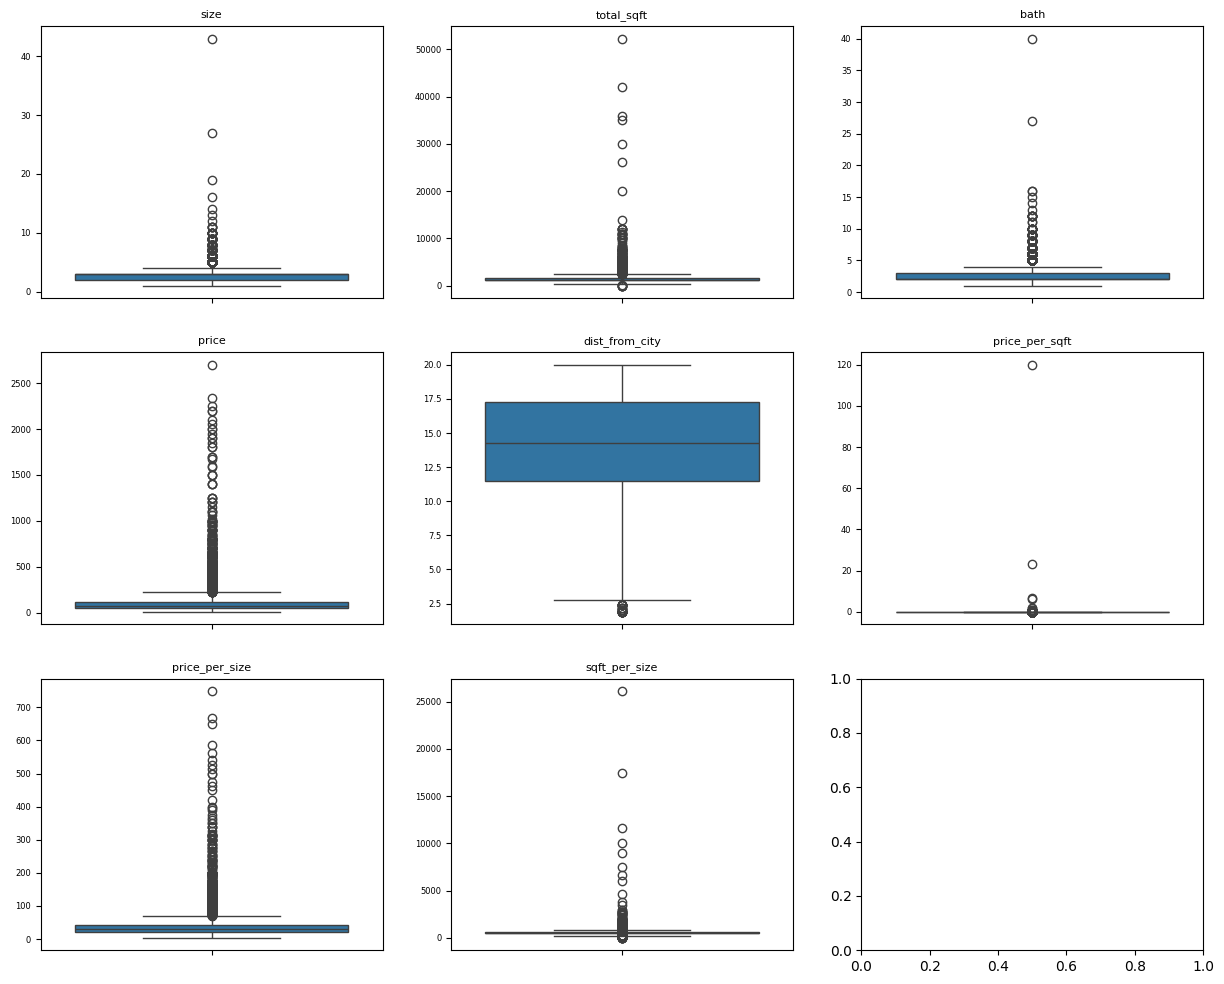

In [369]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

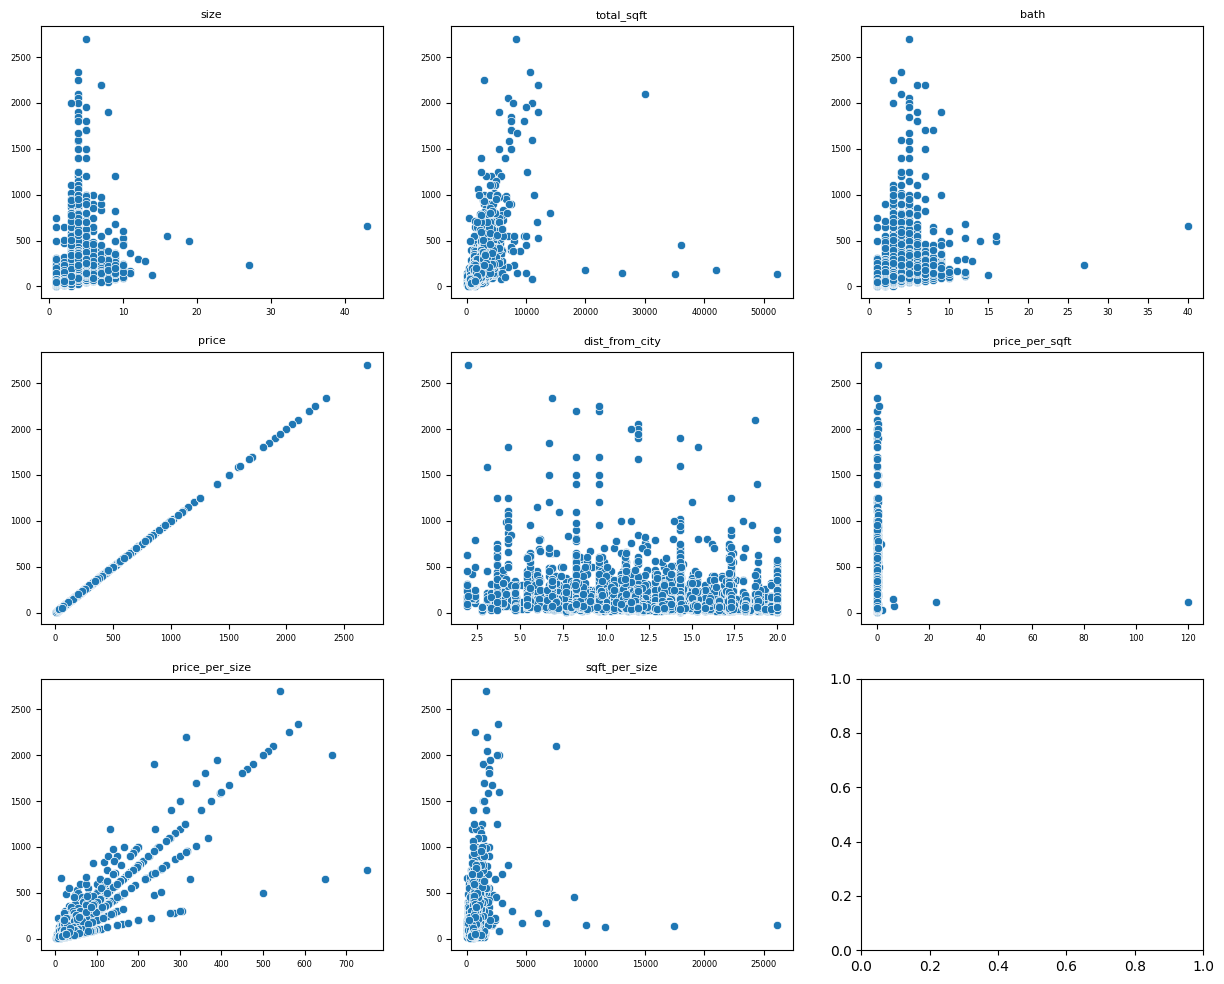

In [370]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [371]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'price', 'dist_from_city', 'price_per_sqft', 'price_per_size',
       'sqft_per_size'],
      dtype='object')

In [372]:
train_df_copy['total_sqft'].describe()

count    10641.000000
mean      1557.815576
std       1271.757811
min          1.000000
25%       1100.000000
50%       1272.000000
75%       1674.000000
max      52272.000000
Name: total_sqft, dtype: float64

In [373]:
train_df_copy['size'].value_counts()

size
2.0     4427
3.0     3870
4.0     1137
1.0      536
5.0      282
6.0      175
7.0       77
8.0       68
9.0       48
10.0      10
11.0       4
27.0       1
19.0       1
16.0       1
43.0       1
14.0       1
12.0       1
13.0       1
Name: count, dtype: int64

In [374]:
train_df_copy = train_df_copy[train_df_copy['size']<9]

In [375]:
train_df_copy.shape

(10572, 11)

In [376]:
train_df_copy['size'].value_counts()

size
2.0    4427
3.0    3870
4.0    1137
1.0     536
5.0     282
6.0     175
7.0      77
8.0      68
Name: count, dtype: int64

In [377]:
loc_max = train_df_copy.groupby('location')['price_per_sqft'].quantile(0.997)

In [378]:
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] < (train_df_copy['location'].map(loc_max))]

In [379]:
train_df_copy = train_df_copy[train_df_copy['bath'] < train_df_copy['size']+2]

In [380]:
def remove_location_outliers(x):
    low_sz = x['price_per_size'].quantile(0.005)
    high_sz = x['price_per_size'].quantile(0.995)

    low_sqft = x['price_per_sqft'].quantile(0.005)
    high_sqft = x['price_per_sqft'].quantile(0.995)

    low_sqft_sz = x['sqft_per_size'].quantile(0.005)
    high_sqft_sz = x['sqft_per_size'].quantile(0.995)

    # Apply the filters all at once
    filtered_x = x[
        # (x['price_per_size'] > low_sz) & (x['price_per_size'] < high_sz) &
        (x['price_per_sqft'] > low_sqft) & (x['price_per_sqft'] < high_sqft)
        # & (x['sqft_per_size'] > low_sqft_sz) & (x['sqft_per_size'] < high_sqft_sz) 
    ]
    
    return filtered_x


In [381]:
train_df_copy = train_df_copy.groupby('location').apply(remove_location_outliers).reset_index(drop=True)

/var/folders/93/b9x72wls10ngnnvdx1_lkf300000gn/T/ipykernel_27232/4116442345.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_df_copy = train_df_copy.groupby('location').apply(remove_location_outliers).reset_index(drop=True)


In [382]:
low_sz = train_df_copy['price_per_size'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['price_per_size'] > low_sz]

low_sqft = train_df_copy['price_per_sqft'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] > low_sqft]

# low_sqft_sz = train_df_copy['sqft_per_size'].quantile(0.003)
# train_df_copy = train_df_copy[train_df_copy['sqft_per_size'] > low_sqft_sz]

low_sqft_total = train_df_copy['total_sqft'].quantile(0.003)
train_df_copy = train_df_copy[train_df_copy['total_sqft'] > low_sqft_total]

high_sqft = train_df_copy['price_per_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['price_per_sqft'] < high_sqft]

# high_sz = train_df_copy['price_per_size'].quantile(0.997)
# train_df_copy = train_df_copy[train_df_copy['price_per_size'] < high_sz]

# high_sqft_sz = train_df_copy['sqft_per_size'].quantile(0.997)
# train_df_copy = train_df_copy[train_df_copy['sqft_per_size'] < high_sqft_sz]

high_sqft_total = train_df_copy['total_sqft'].quantile(0.997)
train_df_copy = train_df_copy[train_df_copy['total_sqft'] < high_sqft_total]

# high_price = train_df_copy['price'].quantile(0.997)
# train_df_copy = train_df_copy[train_df_copy['price'] < high_price]

In [383]:
train_df_copy.shape

(9583, 11)

In [384]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'price', 'dist_from_city', 'price_per_sqft', 'price_per_size',
       'sqft_per_size'],
      dtype='object')

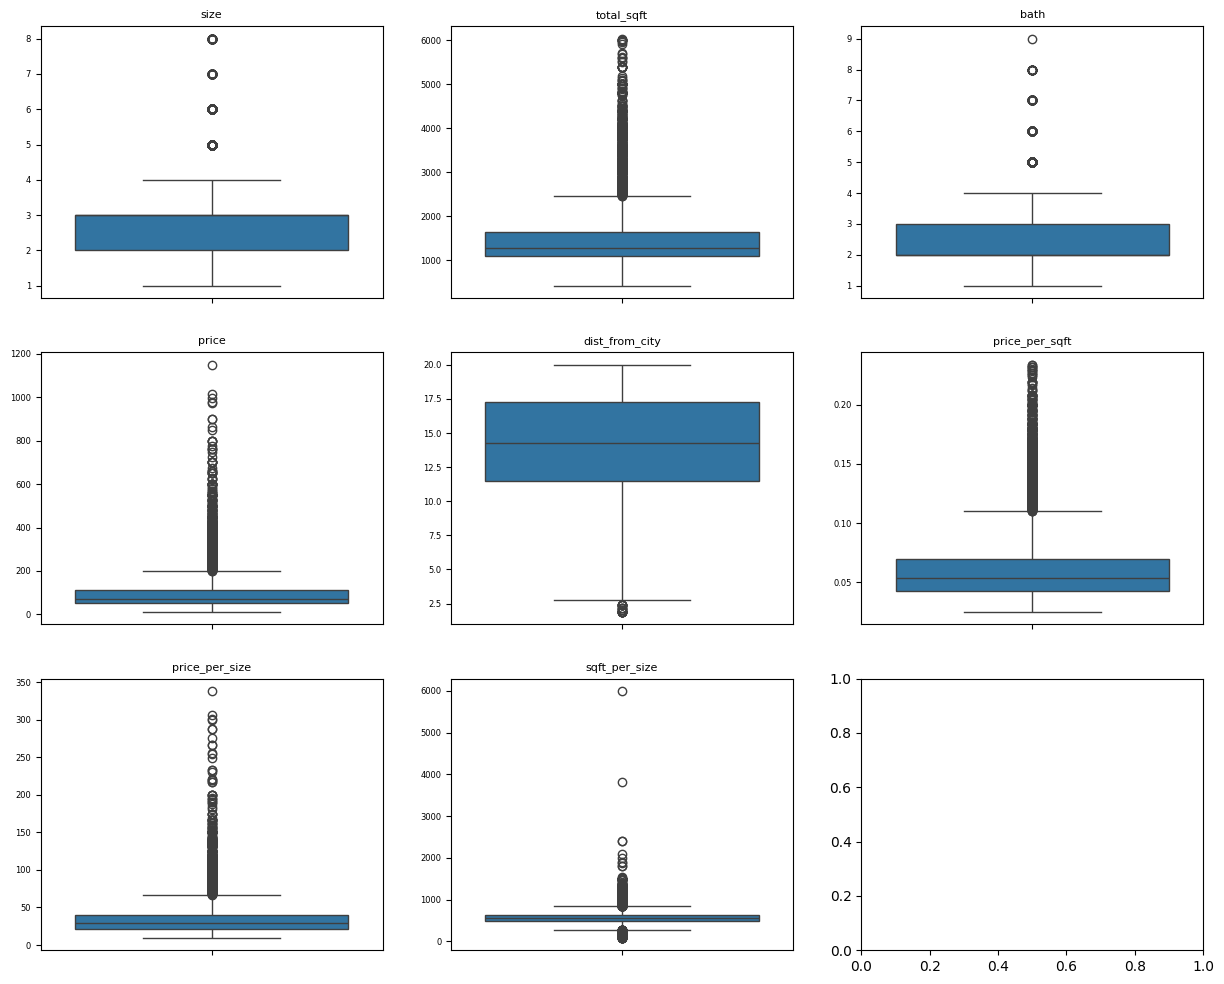

In [385]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [386]:
train_df_copy.drop(columns=['price_per_sqft', 'price_per_size', 'sqft_per_size'], inplace=True)

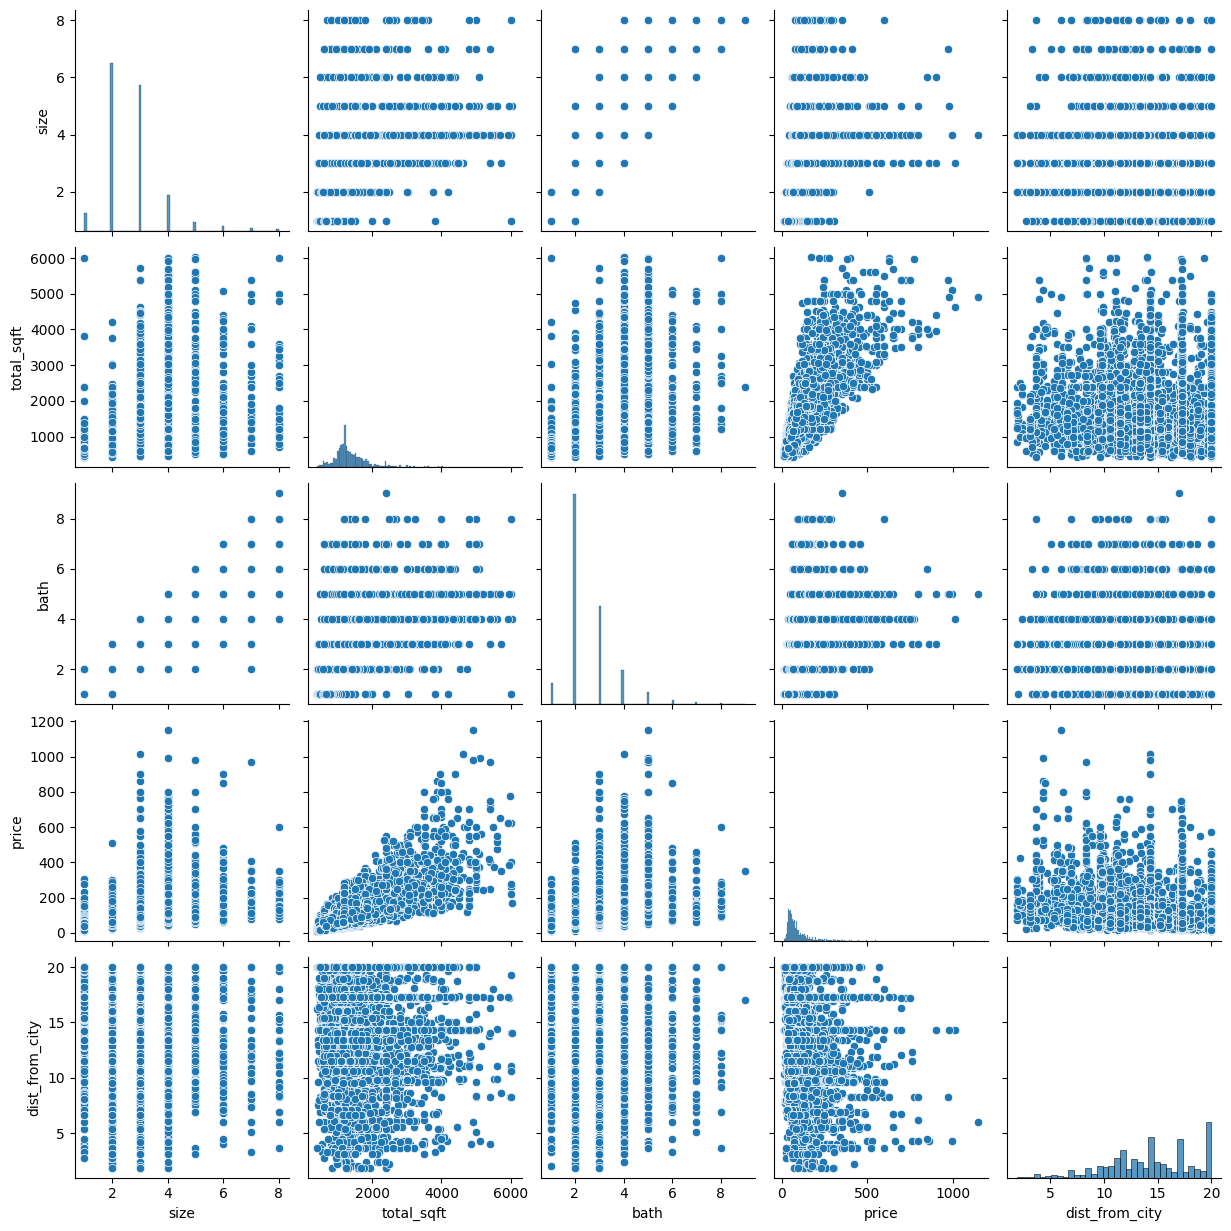

In [387]:
sns.pairplot(train_df_copy)

In [388]:
def outliers(x):
    df = x.copy()
    cols = df.select_dtypes(exclude='object').columns
    for col in cols:
        if col == 'price' or col == 'total_sqft':
            continue
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        minimum = Q1 - IQR*1.5
        maximum = Q3 + IQR*1.5
        df.loc[df[col] < minimum, col] = minimum
        df.loc[df[col] > maximum, col] = maximum
    df[['size', 'bath']] = df[['size', 'bath']].astype('int')
    return df

In [389]:
train_df_copy = outliers(train_df_copy)

In [390]:
test_df_copy = outliers(test_df_copy)

In [391]:
test_df_copy.shape

(2664, 8)

In [392]:
train_df_copy.shape

(9583, 8)

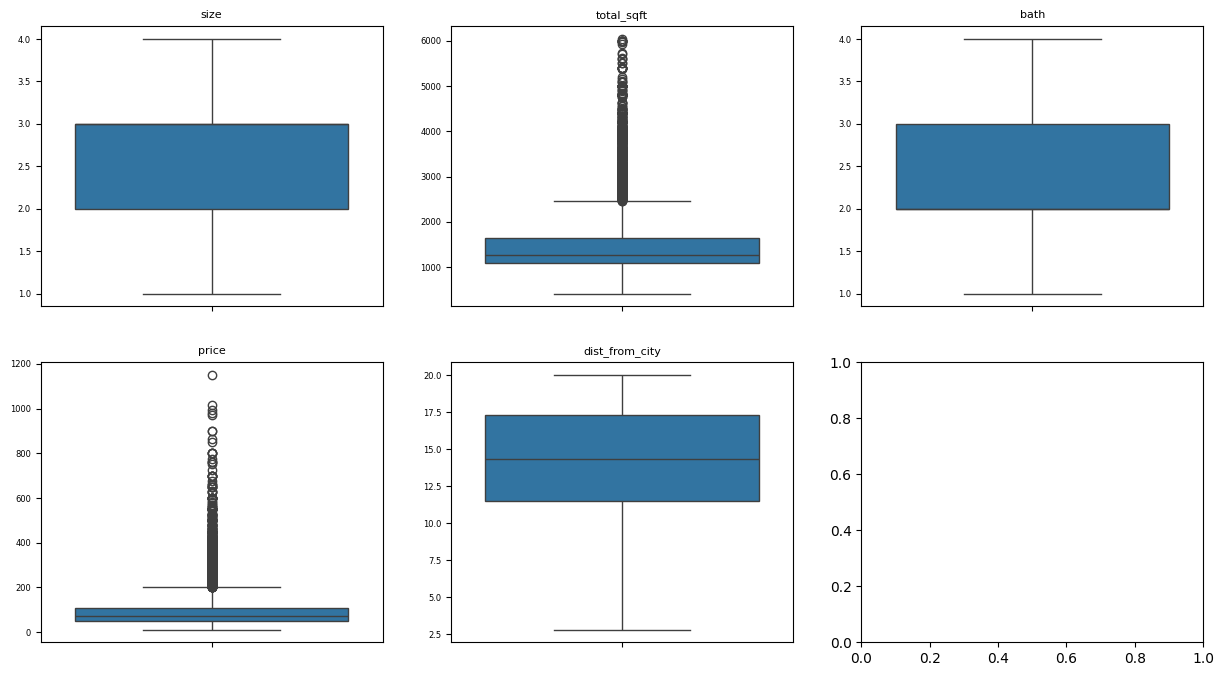

In [393]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(y=num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

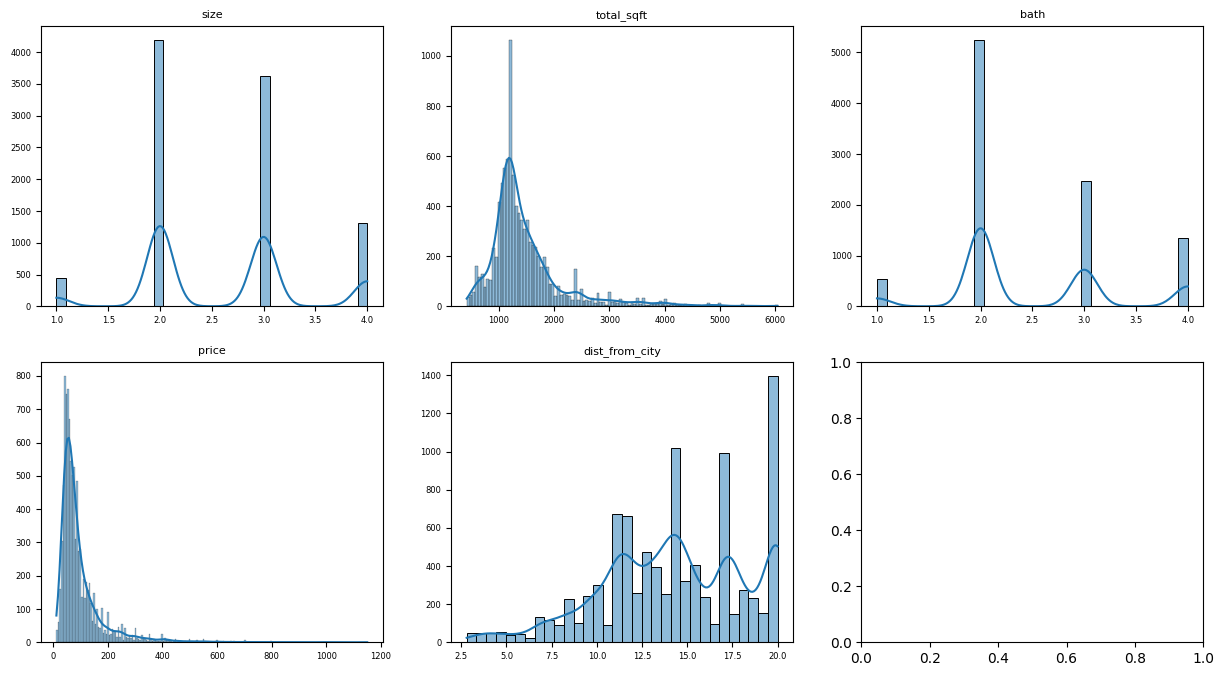

In [394]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

<Axes: xlabel='total_sqft', ylabel='Count'>

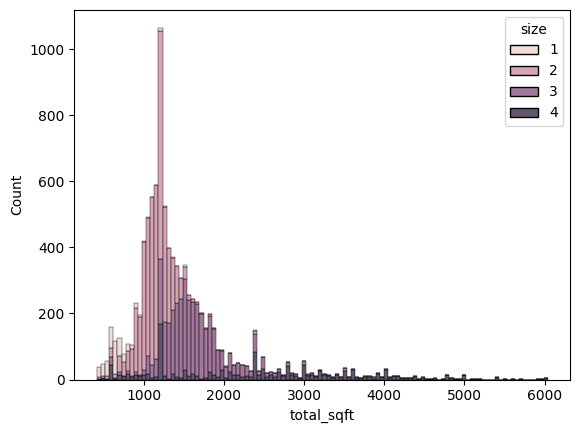

In [395]:
sns.histplot(data=train_df_copy, x='total_sqft', hue='size', multiple='stack')

In [396]:
train_df_copy['total_sqft'] = np.log1p(train_df_copy['total_sqft'])

In [397]:
test_df_copy['total_sqft'] = np.log1p(test_df_copy['total_sqft'])

<Axes: xlabel='total_sqft', ylabel='Count'>

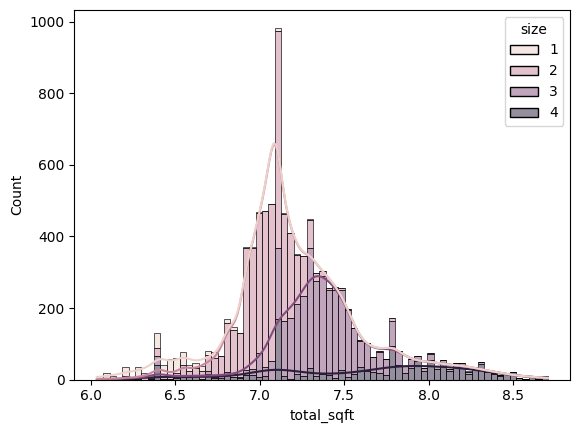

In [398]:
sns.histplot(data=train_df_copy, x='total_sqft', hue='size', multiple='stack', kde=True)

In [399]:
num_df

,size,total_sqft,bath,price,dist_from_city
0,4,2850.0,4,428.00,6.0
1,3,1630.0,3,194.00,6.0
2,4,1200.0,4,125.00,6.0
3,3,1875.0,2,235.00,6.0
4,2,1000.0,3,60.00,6.0
...,...,...,...,...,...
9738,2,1415.0,2,120.00,13.4
9739,2,1164.0,2,64.08,13.4
9740,3,1520.0,3,85.00,13.4
9741,3,1677.0,3,92.13,13.4


In [400]:
test_df_copy.shape

(2664, 8)

In [401]:
tst_ans = pd.read_csv('Datasets/bengaluru_house_prices.csv')

In [402]:
tst_ans.columns

Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

In [403]:
tst_ans.iloc[10656:].drop(columns=['area_type', 'availability', 'location', 'size','total_sqft', 'bath', 'balcony',]).shape

(2664, 2)

In [404]:
test_df_copy.select_dtypes(exclude='object').shape

(2664, 5)

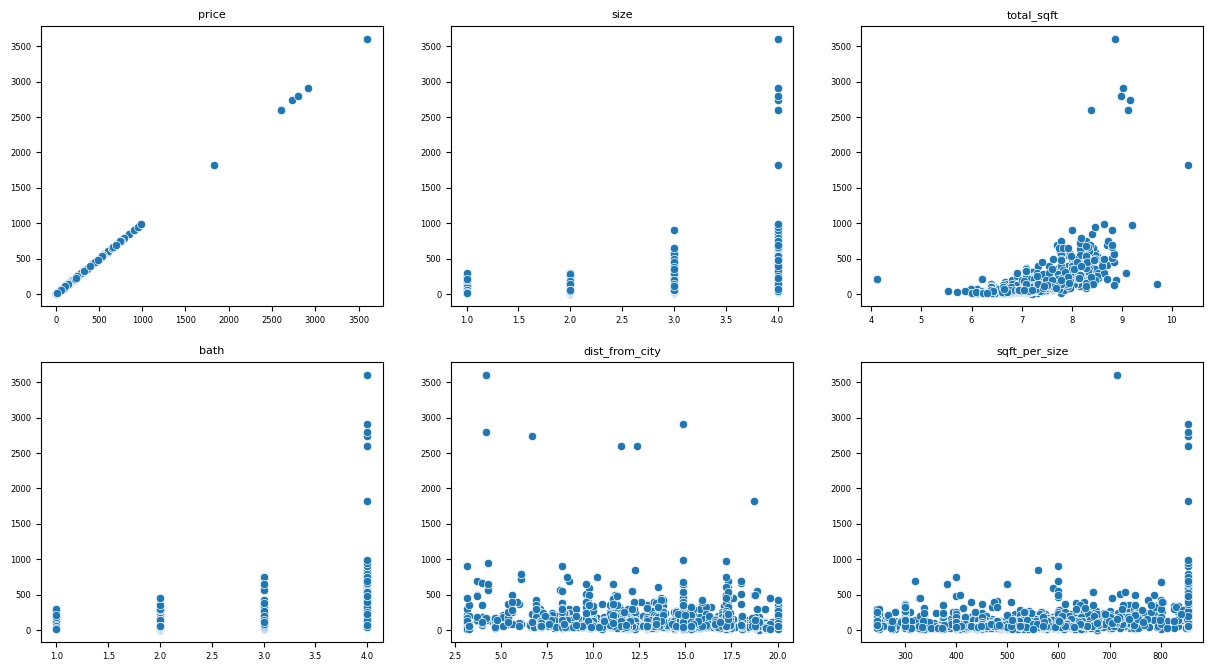

In [405]:
df1 = tst_ans.iloc[10656:].drop(columns=['area_type', 'availability', 'location', 'society', 'size','total_sqft', 'bath', 'balcony']).reset_index(drop=True)
df2 = test_df_copy.select_dtypes(exclude='object').reset_index(drop=True)

num_df = pd.concat([df1, df2], axis=1)

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

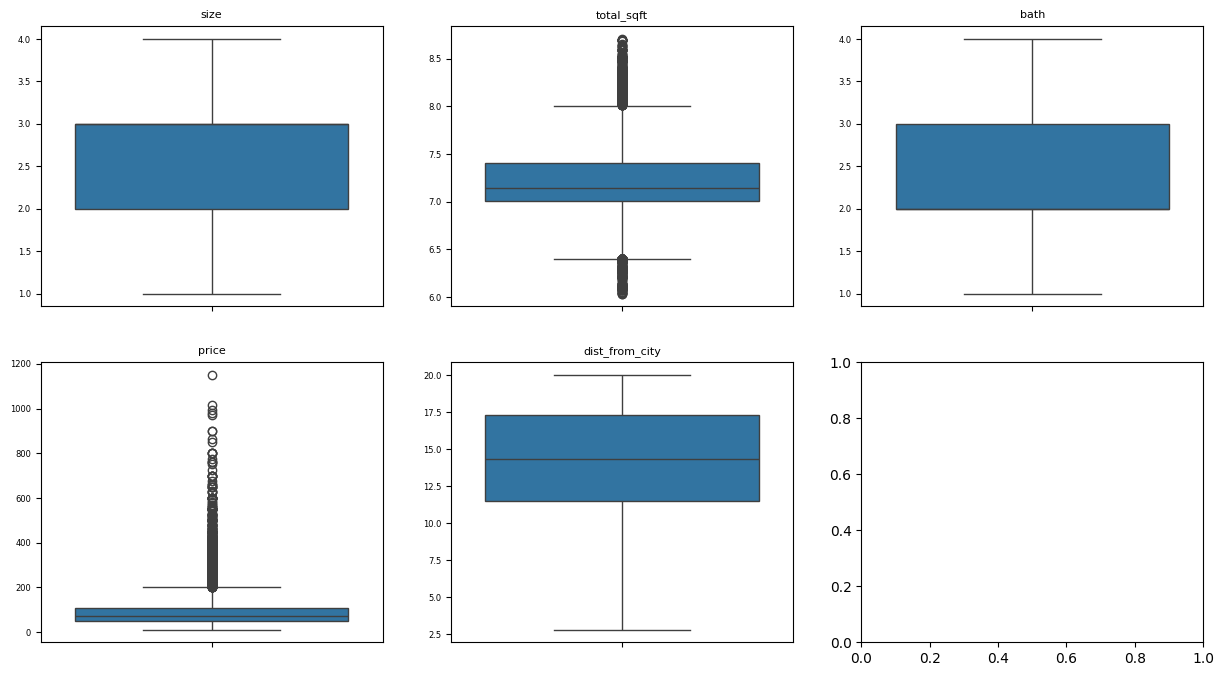

In [406]:
num_df = train_df_copy.select_dtypes(exclude='object')

ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.boxplot(num_df[val], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [407]:
train_df_copy = train_df_copy[train_df_copy['price'] < 1000]

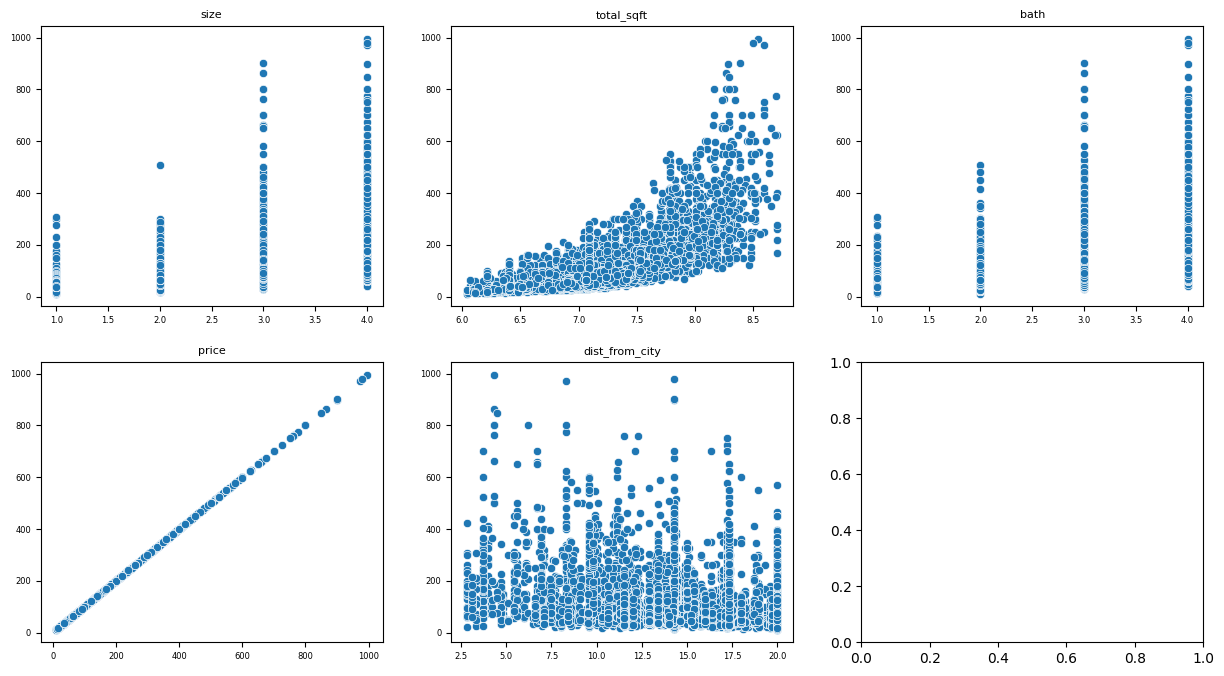

In [408]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.scatterplot(x=num_df[val], y=num_df['price'], ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

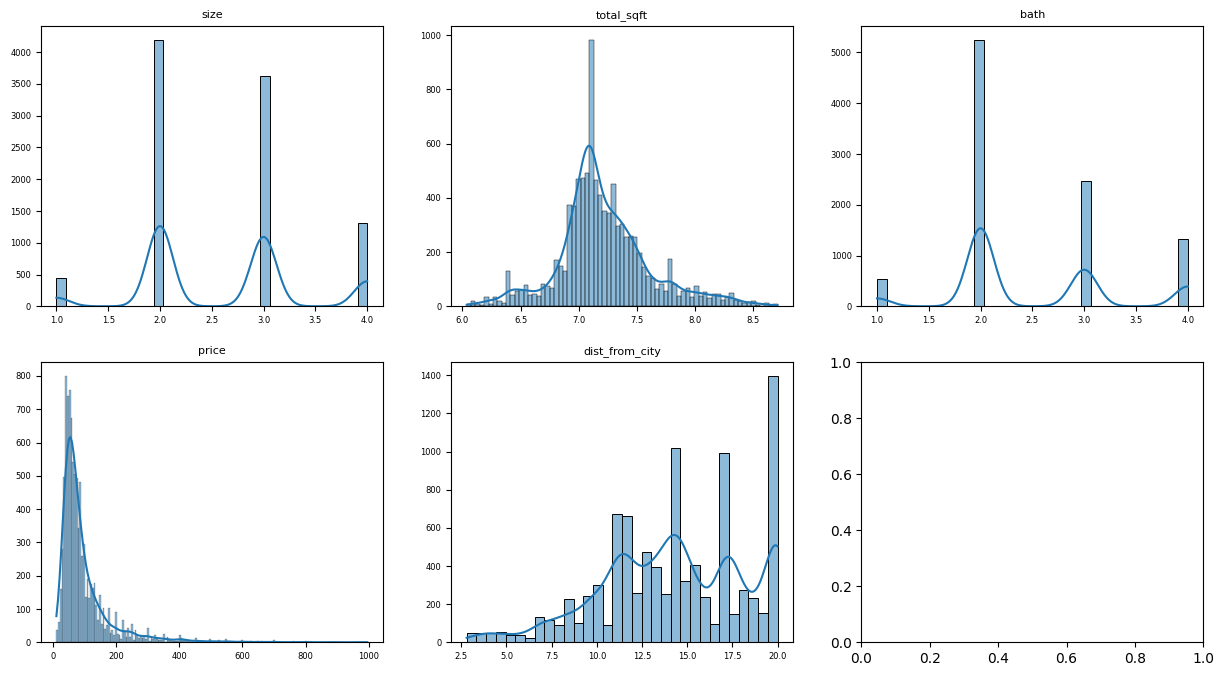

In [409]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [410]:
corr = train_df_copy.corr(numeric_only=True)

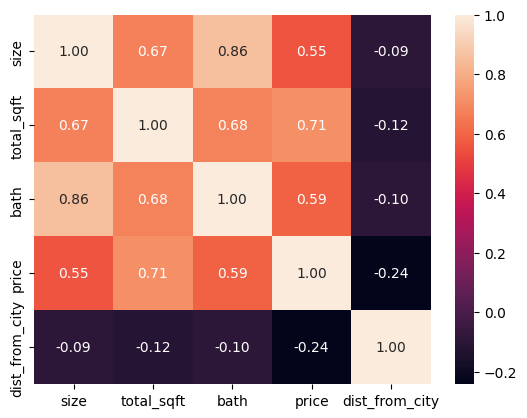

In [411]:
sns.heatmap(corr, annot=True, fmt='0.2f')
plt.show()

In [412]:
train_df_copy

,area_type,location,size,society,total_sqft,bath,price,dist_from_city
0,Super built-up Area,1st Block Jayanagar,4,NoSociety,7.955425,4,428.00,6.0
1,Super built-up Area,1st Block Jayanagar,3,NoSociety,7.396949,3,194.00,6.0
2,Super built-up Area,1st Block Jayanagar,4,NoSociety,7.090910,4,125.00,6.0
3,Super built-up Area,1st Block Jayanagar,3,NoSociety,7.536897,2,235.00,6.0
4,Super built-up Area,1st Block Jayanagar,2,NoSociety,6.908755,3,60.00,6.0
...,...,...,...,...,...,...,...,...
9738,Super built-up Area,Yeshwanthpur,2,NoSociety,7.255591,2,120.00,13.4
9739,Super built-up Area,Yeshwanthpur,2,IBityin,7.060476,2,64.08,13.4
9740,Super built-up Area,Yeshwanthpur,3,IBityin,7.327123,3,85.00,13.4
9741,Super built-up Area,Yeshwanthpur,3,IBityin,7.425358,3,92.13,13.4


In [413]:
train_df_copy

,area_type,location,size,society,total_sqft,bath,price,dist_from_city
0,Super built-up Area,1st Block Jayanagar,4,NoSociety,7.955425,4,428.00,6.0
1,Super built-up Area,1st Block Jayanagar,3,NoSociety,7.396949,3,194.00,6.0
2,Super built-up Area,1st Block Jayanagar,4,NoSociety,7.090910,4,125.00,6.0
3,Super built-up Area,1st Block Jayanagar,3,NoSociety,7.536897,2,235.00,6.0
4,Super built-up Area,1st Block Jayanagar,2,NoSociety,6.908755,3,60.00,6.0
...,...,...,...,...,...,...,...,...
9738,Super built-up Area,Yeshwanthpur,2,NoSociety,7.255591,2,120.00,13.4
9739,Super built-up Area,Yeshwanthpur,2,IBityin,7.060476,2,64.08,13.4
9740,Super built-up Area,Yeshwanthpur,3,IBityin,7.327123,3,85.00,13.4
9741,Super built-up Area,Yeshwanthpur,3,IBityin,7.425358,3,92.13,13.4


In [414]:
train_df_copy.columns

Index(['area_type', 'location', 'size', 'society', 'total_sqft', 'bath',
       'price', 'dist_from_city'],
      dtype='object')

In [415]:
train_df_copy.select_dtypes(exclude='number')

,area_type,location,society
0,Super built-up Area,1st Block Jayanagar,NoSociety
1,Super built-up Area,1st Block Jayanagar,NoSociety
2,Super built-up Area,1st Block Jayanagar,NoSociety
3,Super built-up Area,1st Block Jayanagar,NoSociety
4,Super built-up Area,1st Block Jayanagar,NoSociety
...,...,...,...
9738,Super built-up Area,Yeshwanthpur,NoSociety
9739,Super built-up Area,Yeshwanthpur,IBityin
9740,Super built-up Area,Yeshwanthpur,IBityin
9741,Super built-up Area,Yeshwanthpur,IBityin


In [416]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))
nrows

2

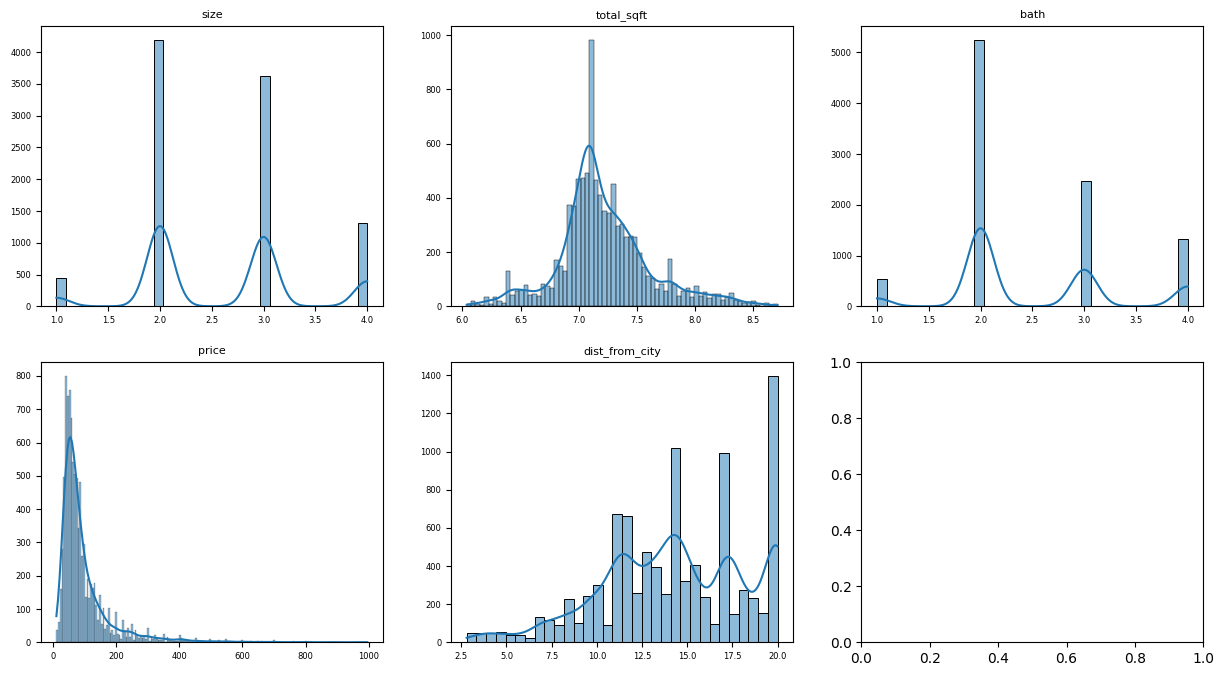

In [417]:
num_df = train_df_copy.select_dtypes(exclude='object')
ncols = 3
nrows = int(np.ceil(len(num_df.columns)/ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*5, nrows*4))
axes = axes.flatten()

for i, val in enumerate(num_df.columns):
    ax = axes[i]
    sns.histplot(x=num_df[val], kde=True, ax=ax)
    ax.tick_params(axis='x', labelsize=6) 
    ax.tick_params(axis='y', labelsize=6)
    ax.set_title(val, fontsize=8)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.show()

In [418]:
def scalar_encoder(x):
    df = x.copy()
    scale_col = ['size','bath', 'total_sqft', 'dist_from_city']
    # log_transform = ['total_sqft']
    # df[log_transform] = np.log1p(df[log_transform])

    scalar = StandardScaler()
    df[scale_col] = scalar.fit_transform(df[scale_col])

    df = pd.concat((df, pd.get_dummies(df[['location','area_type', 'society']], sparse=False, dtype='int')), axis=1)
    df.drop(columns=['location', 'society', 'area_type', 'location_Other', 'area_type_Super built-up  Area', 'society_NoSociety'], inplace=True)

    return df

In [419]:
train_df_copy = scalar_encoder(train_df_copy)

In [420]:
test_df_copy = scalar_encoder(test_df_copy)

In [421]:
missing_cols = set(train_df_copy.columns) - set(test_df_copy.columns)
for col in missing_cols:
    test_df_copy[col] = 0

# Ensure same column order
test_df_copy = test_df_copy[train_df_copy.columns]

In [422]:
test_df_copy

,size,total_sqft,bath,price,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,...,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa
0,-0.824426,-1.721368,-1.835992,0,-1.934612,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.412213,-0.032544,-0.643045,0,-0.866190,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.412213,0.489591,0.549902,0,0.699172,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.824426,-0.745774,-0.643045,0,0.525243,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-2.061065,-0.065866,-1.835992,0,-0.568026,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,1.648852,2.062636,1.742849,0,0.699172,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,1.648852,2.157143,1.742849,0,-2.207929,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2661,-0.824426,-0.446956,-0.643045,0,0.202232,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2662,1.648852,2.756272,1.742849,0,-0.791649,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [423]:
train_df_copy

,size,total_sqft,bath,price,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,...,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa
0,1.793363,1.851474,1.901464,428.00,-2.082682,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.507558,0.451578,0.650404,194.00,-2.082682,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.793363,-0.315550,1.901464,125.00,-2.082682,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.507558,0.802377,-0.600655,235.00,-2.082682,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-0.778247,-0.772146,0.650404,60.00,-2.082682,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9738,-0.778247,0.097247,-0.600655,120.00,-0.221756,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9739,-0.778247,-0.391835,-0.600655,64.08,-0.221756,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9740,0.507558,0.276551,0.650404,85.00,-0.221756,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9741,0.507558,0.522789,0.650404,92.13,-0.221756,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [424]:
train_df_copy.drop(columns=['price'])

,size,total_sqft,bath,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,location_7th Phase JP Nagar,...,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa
0,1.793363,1.851474,1.901464,-2.082682,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.507558,0.451578,0.650404,-2.082682,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1.793363,-0.315550,1.901464,-2.082682,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0.507558,0.802377,-0.600655,-2.082682,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-0.778247,-0.772146,0.650404,-2.082682,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9738,-0.778247,0.097247,-0.600655,-0.221756,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9739,-0.778247,-0.391835,-0.600655,-0.221756,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9740,0.507558,0.276551,0.650404,-0.221756,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9741,0.507558,0.522789,0.650404,-0.221756,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [425]:
X = train_df_copy.drop(columns=['price'])
y = np.log1p(train_df_copy['price'])
train_x, test_x, train_y, test_y = train_test_split(X, y, train_size=0.8, random_state=42)

In [426]:
print(train_x.shape, test_x.shape, train_y.shape, test_y.shape)

(7664, 260) (1917, 260) (7664,) (1917,)


In [427]:
lin_model = LinearRegression()
lin_model.fit(train_x,train_y)


LinearRegression()

In [428]:
lin_model.score(train_x, train_y)

0.825158624553887

In [429]:
lin_model.score(test_x, test_y)

0.8174329627810397

In [430]:
lin_model.predict(test_df_copy.drop(columns='price'))

array([4.12762662, 4.28941057, 4.50734418, ..., 3.93012047, 5.65420568,
       3.02317495])

In [431]:
prc = np.log1p(tst_ans.iloc[10656:]['price'])

In [432]:
prc

10656    3.713572
10657    4.021595
10658    4.672829
10659    4.262680
10660    4.025352
           ...   
13315    5.446737
13316    5.993961
13317    4.110874
13318    6.192362
13319    2.890372
Name: price, Length: 2664, dtype: float64

In [433]:
test_df_copy

,size,total_sqft,bath,price,dist_from_city,location_1st Block Jayanagar,location_1st Phase JP Nagar,location_2nd Stage Nagarbhavi,location_5th Phase JP Nagar,location_6th Phase JP Nagar,...,society_SNnia E,society_Shitt S,society_Soazak,society_Sodgere,society_Soiewre,society_Soitya,society_Soresea,society_Sryalan,society_SunceEs,society_ViistLa
0,-0.824426,-1.721368,-1.835992,0,-1.934612,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.412213,-0.032544,-0.643045,0,-0.866190,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0.412213,0.489591,0.549902,0,0.699172,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,-0.824426,-0.745774,-0.643045,0,0.525243,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,-2.061065,-0.065866,-1.835992,0,-0.568026,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2659,1.648852,2.062636,1.742849,0,0.699172,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2660,1.648852,2.157143,1.742849,0,-2.207929,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2661,-0.824426,-0.446956,-0.643045,0,0.202232,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2662,1.648852,2.756272,1.742849,0,-0.791649,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [434]:
lin_model.score(test_df_copy.drop(columns='price'), prc)

0.7755013871379188

In [435]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0) # ShuffleSplit - Randomize the sample

cross_val_score(LinearRegression(), X, y, cv=cv)

array([0.82155292, 0.81342667, 0.8227015 , 0.81098072, 0.82162739])

In [436]:
features_combined_train_const = sm.add_constant(train_x)
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     134.9
Date:                Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:17:52   Log-Likelihood:                -641.89
No. Observations:                7664   AIC:                             1804.
Df Residuals:                    7404   BIC:                             3609.
Df Model:                         259                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

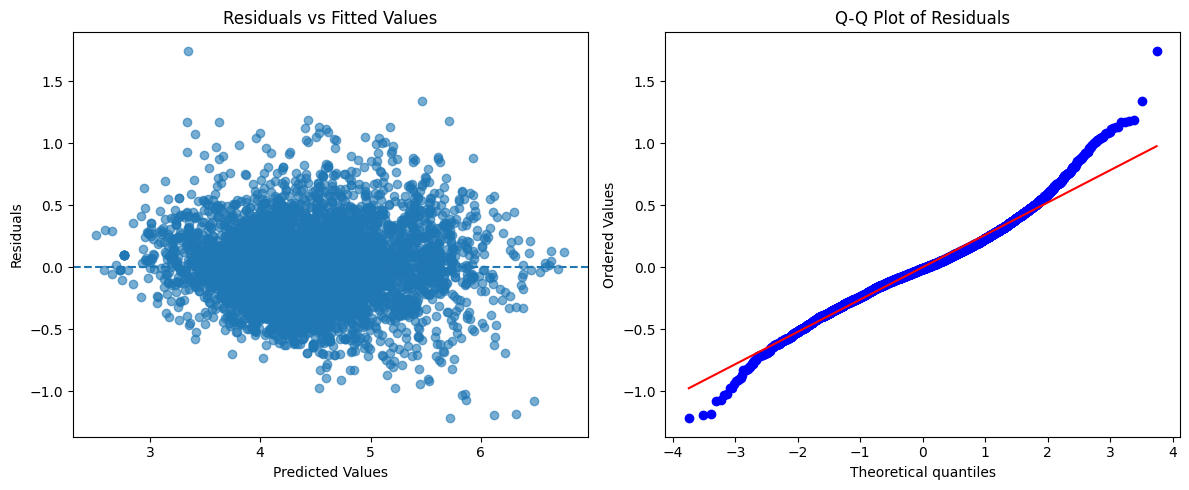

In [437]:
y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [438]:
features_to_keep = train_x.columns.to_list()
while True:
    model = sm.OLS(train_y, sm.add_constant(train_x[features_to_keep])).fit()
    p_values = model.pvalues.drop('const')
    max_p_value = p_values.max()

    if max_p_value > 0.5:
        # Remove the least significant feature
        feature_to_remove = p_values.idxmax()
        features_to_keep.remove(feature_to_remove)
    else:
        # Stop when all remaining features are significant
        break
print(features_to_keep)

['size', 'total_sqft', 'bath', 'dist_from_city', 'location_1st Phase JP Nagar', 'location_2nd Stage Nagarbhavi', 'location_5th Phase JP Nagar', 'location_6th Phase JP Nagar', 'location_7th Phase JP Nagar', 'location_8th Phase JP Nagar', 'location_Abbigere', 'location_Akshaya Nagar', 'location_Ambalipura', 'location_Ambedkar Nagar', 'location_Anandapura', 'location_Ananth Nagar', 'location_Anekal', 'location_Anjanapura', 'location_Ardendale', 'location_Arekere', 'location_Attibele', 'location_BTM Layout', 'location_Babusapalaya', 'location_Balagere', 'location_Banaswadi', 'location_Bannerghatta', 'location_Bannerghatta Road', 'location_Basavangudi', 'location_Basaveshwara Nagar', 'location_Battarahalli', 'location_Begur', 'location_Bellandur', 'location_Benson Town', 'location_Bhoganhalli', 'location_Billekahalli', 'location_Binny Pete', 'location_Bommanahalli', 'location_Bommasandra', 'location_Brookefield', 'location_Budigere', 'location_Byrasandra', 'location_CV Raman Nagar', 'locati

In [439]:
len(features_to_keep)

229

In [440]:
features_combined_train_const = sm.add_constant(train_x[features_to_keep])
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.820
Method:                 Least Squares   F-statistic:                     153.8
Date:                Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:17:58   Log-Likelihood:                -643.08
No. Observations:                7664   AIC:                             1744.
Df Residuals:                    7435   BIC:                             3334.
Df Model:                         228                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

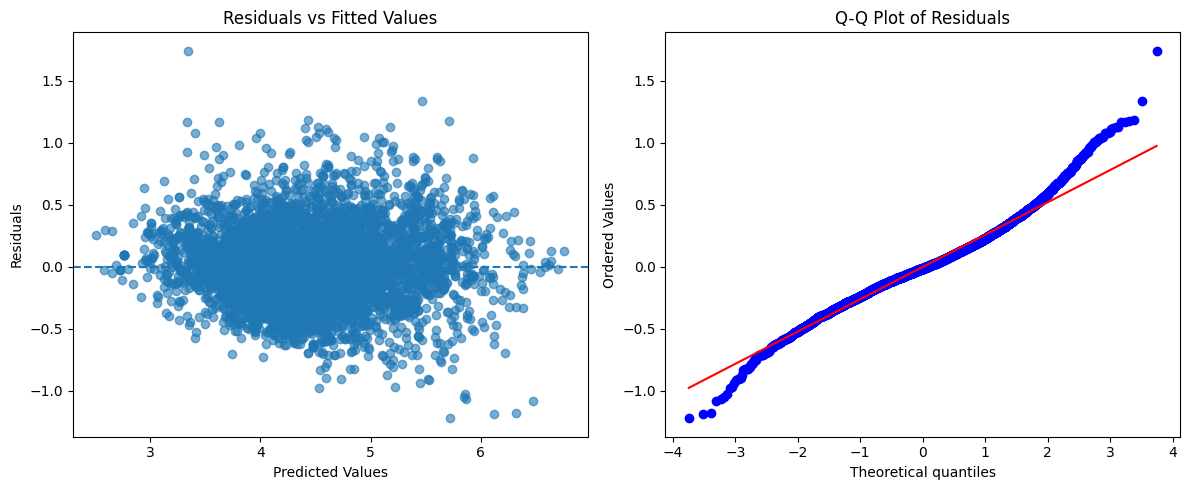

In [441]:
y_pred = model.predict(features_combined_train_const)
residuals = model.resid
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [442]:
corr = train_df_copy.corr().abs()

high_corr = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))\
                .stack()\
                .sort_values(ascending=False)

high_corr[high_corr > 0.85]


location_Lingadheeranahalli  society_Soiewre    1.000000
location_Bisuvanahalli       society_Prityel    0.987045
location_Budigere            society_PrityTr    0.985962
location_Balagere            society_Soresea    0.927718
location_Thigalarapalya      society_Prtanha    0.906385
size                         bath               0.857247
dtype: float64

In [443]:
print(train_df_copy.corr(numeric_only=True).abs()['price'][[item[0] for item in high_corr[high_corr > 0.85].index.to_list()]])

location_Lingadheeranahalli    0.005860
location_Bisuvanahalli         0.041358
location_Budigere              0.020192
location_Balagere              0.026394
location_Thigalarapalya        0.030629
size                           0.554845
Name: price, dtype: float64


In [444]:
print(train_df_copy.corr(numeric_only=True).abs()['price'][[item[1] for item in high_corr[high_corr > 0.85].index.to_list()]])

society_Soiewre    0.005860
society_Prityel    0.040912
society_PrityTr    0.019175
society_Soresea    0.025637
society_Prtanha    0.034536
bath               0.589257
Name: price, dtype: float64


In [445]:
second_features = [item[1] for item in high_corr[high_corr > 0.85].index.to_list()]
print(second_features)

['society_Soiewre', 'society_Prityel', 'society_PrityTr', 'society_Soresea', 'society_Prtanha', 'bath']


In [446]:
features_to_keep = list(set(train_x.columns) - set(['location_Lingadheeranahalli', 'society_Prityel','society_PrityTr ', 'society_Soresea', 'location_Thigalarapalya']) - {'size'})

In [447]:
model = LinearRegression()
model.fit(train_x[features_to_keep],train_y)

LinearRegression()

In [448]:
model.score(test_x[features_to_keep], test_y)

0.8166998411184472

In [449]:
model.predict(train_x[features_to_keep])

array([5.70511318, 4.05903158, 3.93831142, ..., 4.83699764, 3.93184179,
       5.25440809])

In [450]:
model.score(test_df_copy[features_to_keep], prc)

0.7749167430974094

In [451]:
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_values = []

    for col in df.columns:
        X = df.drop(columns=[col])
        y = df[col]

        model = LinearRegression().fit(X, y)
        r2 = model.score(X, y)
        if r2 == 1:
            vif = float("inf")
        else:
            vif = 1 / (1 - r2)
        vif_values.append(vif)

    vif_data["VIF"] = vif_values
    return vif_data

In [452]:
vif_table = calculate_vif(train_x[features_to_keep])
print(vif_table)

                           feature       VIF
0            location_Channasandra  1.060765
1               location_Kambipura  1.030851
2               location_Jayanagar  1.119954
3                  location_Harlur  1.501330
4         location_Padmanabhanagar  1.011048
..                             ...       ...
250  location_Lakshminarayana Pura  2.346427
251          location_Kundalahalli  2.363290
252            location_Nagarbhavi  1.041414
253           location_Mahadevpura  1.017942
254          location_Sonnenahalli  1.011343

[255 rows x 2 columns]


In [453]:
vif_table[vif_table['VIF'] > 10]

,feature,VIF
153,location_Budigere,29.975255
211,society_PrityTr,29.901384


In [454]:
vif_table[vif_table['VIF'] > 10]['feature'].to_list()

['location_Budigere', 'society_PrityTr']

In [455]:
col_to_ex = list(set(train_x.columns.to_list()) - set(vif_table[vif_table['VIF'] > 10]['feature'].to_list()))

In [456]:
features_combined_train_const = sm.add_constant(train_x[col_to_ex])
model = sm.OLS(train_y, features_combined_train_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.825
Model:                            OLS   Adj. R-squared:                  0.819
Method:                 Least Squares   F-statistic:                     135.8
Date:                Wed, 05 Nov 2025   Prob (F-statistic):               0.00
Time:                        15:19:39   Log-Likelihood:                -647.36
No. Observations:                7664   AIC:                             1811.
Df Residuals:                    7406   BIC:                             3602.
Df Model:                         257                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [457]:
ridge_params = {
    "alpha": [0.1, 0.8, 1, 2, 3, 5, 10],
    "fit_intercept": [True, False],
    "solver": ["auto","sag", "saga"]
}

In [458]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
gs_rid = GridSearchCV(Ridge(), ridge_params , cv=cv, return_train_score=False)
gs_rid.fit(train_x[features_to_keep],train_y)
print(gs_rid.best_params_)
print(gs_rid.best_score_)

{'alpha': 0.8, 'fit_intercept': True, 'solver': 'auto'}
0.8157202648351276


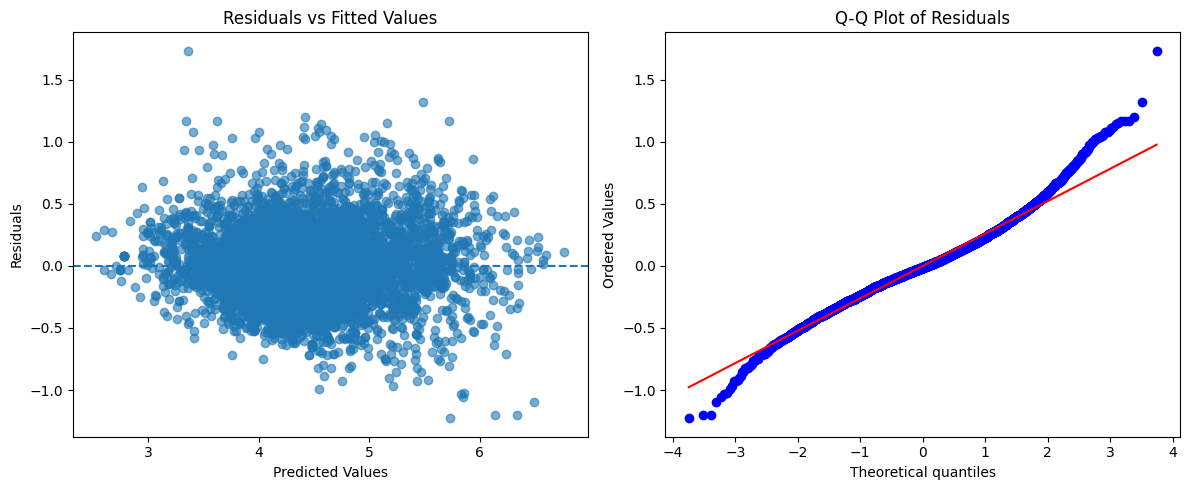

In [459]:
y_pred = gs_rid.predict(train_x[features_to_keep])
residuals = train_y - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

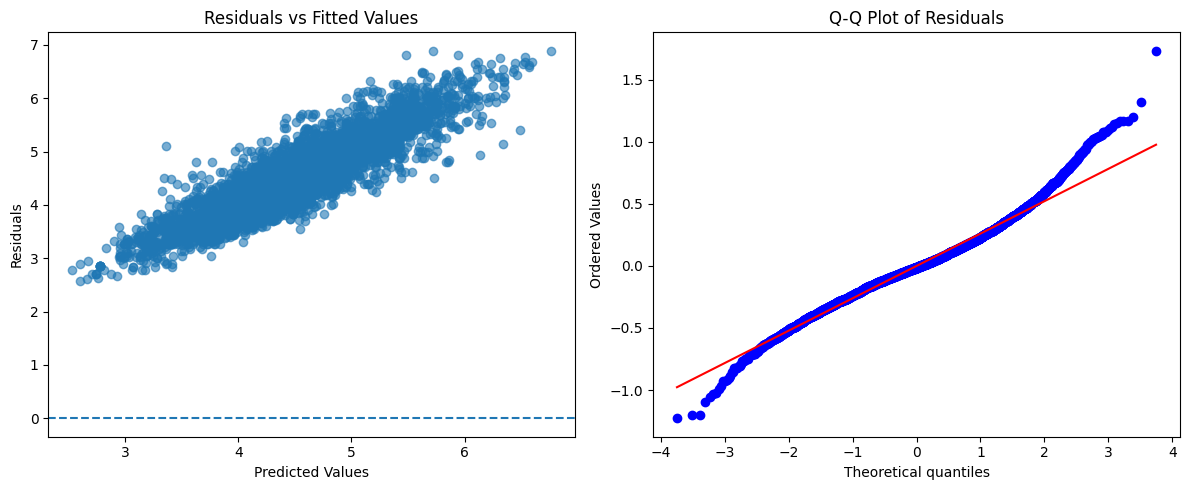

In [460]:
y_pred = gs_rid.predict(train_x[features_to_keep])
residuals = train_y - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, train_y, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [461]:
lasso_params = {
    "alpha": [0.00005, 0.00001, 0.0001],
    "fit_intercept": [True, False],
    "selection": ["cyclic", "random"]
}

In [462]:
cv = ShuffleSplit(n_splits=5, test_size=0.2, random_state=0)
gs_las = GridSearchCV(Lasso(), lasso_params , cv=cv, return_train_score=False)
gs_las.fit(train_x[features_to_keep],train_y)
print(gs_las.best_params_)
print(gs_las.best_score_)

{'alpha': 1e-05, 'fit_intercept': True, 'selection': 'cyclic'}
0.815777652063946


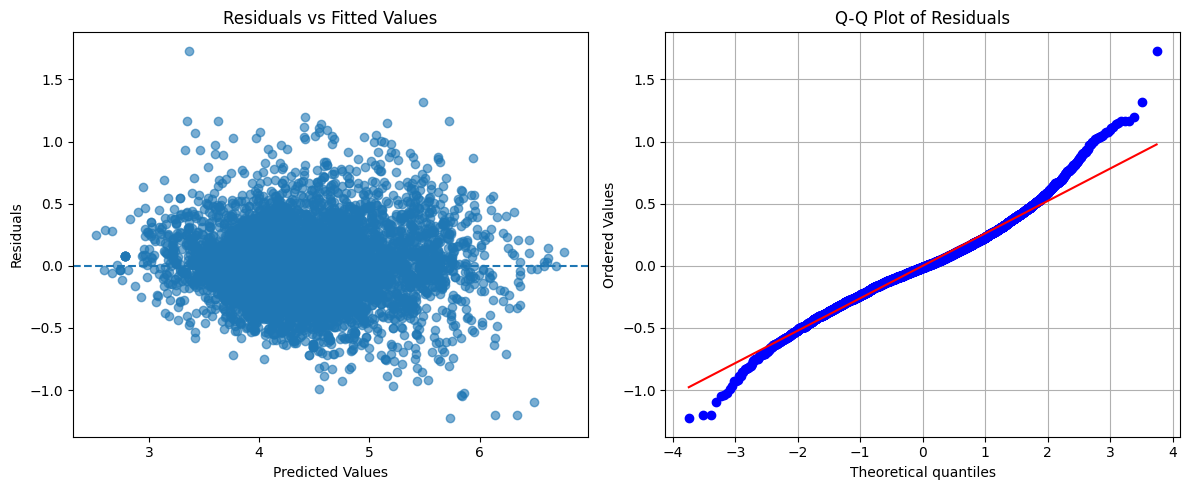

In [463]:
y_pred = gs_las.predict(train_x[features_to_keep])
residuals = train_y - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.grid(True)
plt.show()

In [485]:
y_pred = gs_las.predict(train_x[features_to_keep])
residuals = train_y - y_pred

residuals[residuals.abs() > 1]

5338    1.022462
6092    1.047135
4711   -1.047226
6501    1.005343
2498    1.073000
6038   -1.037779
3597    1.093280
6694    1.168070
5736   -1.200074
5728    1.149290
5422    1.142229
5324    1.030530
8740   -1.203984
5374    1.161835
692    -1.227527
5321    1.075814
5951    1.731461
6120    1.200445
6259    1.048701
3590   -1.024840
5474    1.166486
2724   -1.094215
6609    1.023553
6207    1.037390
5556    1.032275
6196    1.112254
763     1.076469
6317    1.320902
6608    1.115058
5533    1.054620
7039    1.038897
Name: price, dtype: float64

In [491]:
train_df['price'].describe()

count    10656.000000
mean       112.214256
std        142.231967
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       2700.000000
Name: price, dtype: float64

In [464]:
gs_rid.score(test_df_copy[features_to_keep], prc)

0.7751434296159713

In [465]:
pred = gs_rid.predict(test_df_copy[features_to_keep])

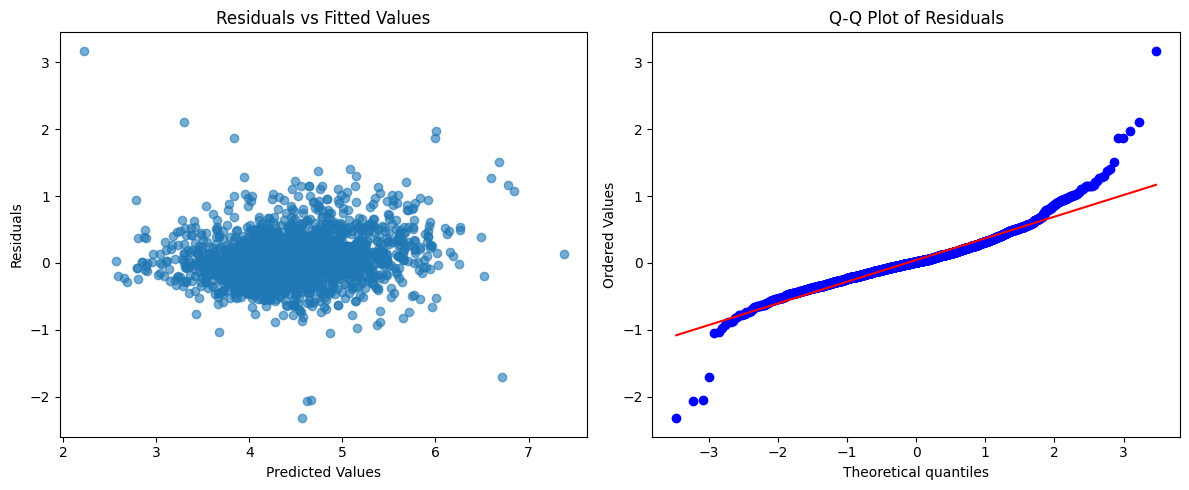

In [466]:
y_pred = pred
residuals = prc - y_pred
plt.figure(figsize=(12,5))

# 1. Residual Plot
plt.subplot(1, 2, 1)
plt.scatter(pred, residuals, alpha=0.6)
# plt.axhline(y=0, linestyle='--')
plt.title("Residuals vs Fitted Values")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

# 2. Q-Q Plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()

In [467]:
np.square(mean_squared_error(prc, gs_rid.predict(test_df_copy[features_to_keep])))

0.013073086529776637

In [468]:
gs_las.score(test_df_copy[features_to_keep], prc)

0.7750612480869754

In [469]:
np.square(mean_squared_error(prc, gs_las.predict(test_df_copy[features_to_keep])))

0.01308264428981747